# **Machine learning: Reconnaissance de sorts (magiques)**

## 1. Introduction

### a) Rappels

Ce notebook fait suite au TP Perceptron dans lequel nous avions construit un petit réseau de neurones - appelé **perceptron** - pour effectuer de la reconnaissance de caractères.


<img src="https://github.com/PlantecJY/python-mic/raw/master/principe.png" alt="Drawing" width="300" align="center"/>


Nous avions suivi les étapes ci-dessous :
* **Structuration des données** pour l’apprentissage (un dictionnaire de chiffres écrits représentés par des tableaux 5*6, comme dans l'exemple ci-dessous

```
nb9b = [[1,1,1,1,1],
        [1,0,0,0,1],
        [1,0,0,0,1],
        [1,1,1,1,1],
        [0,0,0,0,1],
        [1,1,1,1,1]]
```
* **Création du réseau de neurones** : une couche d'entrée de dimension 300 et une couche de sortie de dimension 10 ; l'information passée à chaque neurone de sortie était simplement la combinaison linéaire des neurones reliés à cette sortie pondérée par le poids de chaque neurone ;
* **Test** du fonctionnement du réseau de neurones ;
* **Apprentissage**, c'est-dire-optimisation du poids de chaque neurone ;
* Utilisation du réseau de neurones pour une faire une **prédiction** : on fournit un chiffre sous forme de tableau et on demande au réseau de prédire ce chiffre.

### b) Objectif de ce TP

Dans ce TP, l'objectif est de comprendre toute la **chaîne d'apprentissage en Machine Learning** à travers le domaine de la **reconnaissance de gestes**, et plus particulièrement de sorts (magiques). Nous allons donc passer par les étapes suivantes:
  1) Acquisition des données brutes et construction d'un **dataset**
  2) **Split** données d'entraînement/ données de test
  3) **Pré-traitement** des données (génération de features)
  4) **Entraînement** d'un modèle léger (réseau de neurones)
  5) **Test** du modèle
  6) **Déploiement embarqué** sur une carte

 
### c) Etapes à suivre

1) **PARTIE 1**: Comprendre toute la chaîne d'apprentissage à travers un dataset prêt
2) **PARTIE 2**: Déploiement embarqué sur carte
3) **PARTIE 3**: Compléter la base de donnée: ajoutez un nouveau geste et refaire la chaîne d'apprentissage jusqu'au déploiement.

## **PARTIE 1: Comprendre la chaîne d'apprentissage en machine learning**

## 1. Construction d'un dataset

Pour cette première étape, nous allons télécharger une base de données contenant déjà un certains nombre de gestes par **label** (qui sont au nombre de 3):
* 100 gestes du sort "**Wingardium Leviosa**"
* 100 gestes du sort "**Stupefy**"
* 100 gestes du sort "**Expelliarmus**"

Les gestes sont enregistrés, carte à la main, pendant une durée de **5 secondes**, il est important de respecter ce temps d'acquisition pour l'enregistrement de nouvelles données.

L'objectif ici est de construire un tableau sur Python contenant les données que l'on pourra ensuite traîter pour entraîner/tester le modèle futur.


### a) Importation des bibliothèques nécessaires

In [1]:
#Une fois cette ligne executée, Restart Kernel

%pip install pyserial

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import zipfile
import os
import glob
import json
import pandas as pd
import os

### b) Upload d'un dataset et rangement des données dans un tableau

Remarque: ici, les données sont dites "**brutes**", elles ne sont pas encore traitées pour entraîner et tester le modèle, on a ici les acquisitions temporelles de chaque enregistrements de gestes, ce qui donne beaucoup plus de lignes sur le tableau que de fichiers réels.

In [3]:
data = pd.read_csv("dataset_sorts_xiao.csv")

colonnes_attendues = [
    "AxX", "AxY", "AxZ",
    "GxX", "GxY", "GxZ",
    "source_file", "label", "origine",
]

colonnes_manquantes = set(colonnes_attendues) - set(data.columns)
if colonnes_manquantes:
    raise ValueError(f"Colonnes manquantes : {colonnes_manquantes}")

print("Taille du dataset :", data.shape)
display(
    data.groupby("label")["source_file"]
    .nunique()
    .rename("nombre_de_gestes")
    .to_frame()
)

data.head()


Taille du dataset : (75157, 9)


,nombre_de_gestes
label,
Expelliarmus,100
Stupefy,100
Wingardium Leviosa,100


,AxX,AxY,AxZ,GxX,GxY,GxZ,source_file,label,origine
0,-0.417240,-0.122488,0.926712,0.07,-2.31,-1.47,Expelliarmus_001_20260717_125857_459000,Expelliarmus,xiao
1,-0.410408,-0.142496,0.925736,-0.63,-1.12,-1.12,Expelliarmus_001_20260717_125857_459000,Expelliarmus,xiao
2,-0.417728,-0.147376,0.917928,0.21,-0.77,-0.07,Expelliarmus_001_20260717_125857_459000,Expelliarmus,xiao
3,-0.410896,-0.139080,0.936472,-0.98,-1.33,0.63,Expelliarmus_001_20260717_125857_459000,Expelliarmus,xiao
4,-0.404552,-0.135664,0.916952,1.75,0.98,1.61,Expelliarmus_001_20260717_125857_459000,Expelliarmus,xiao


### c) Questions

1) Quelle est la fréquence d'enregistrement des données? (valeur)
2) Que contient le fichier data_sort? (questions à choix multiples)
3) Quelle est la taille du dataset? (valeur)
4) Quelle est la valeur de l'axe Z du gyroscope de la première ligne du tableau de données? Aidez vous de la fonction head. (valeur)
5) Pourquoi est-il important de vérifier la qualité des données avant de commencer l'entraînement d'un modèle ? (questions à choix multiples)
6) Label-->Nom du geste enregistré; Acquisition-->Série de mesures IMU; Dataset-->Ensemble des acquisitions; Feature-->Caractéristique calculée après traitement (Association)

## 2. Split des données en training/test

Dans la deuxième étape de la chaîne d'apprentissage, on va **séparer (split)** les données en 2 catégories:
* Les **données d'entraînement** (training set) qui vont servir à entraîner le modèle, ces données seront elles-mêmes divisées en données d'entraînement et de validation du modèle
* Les **données de test** (test set) qui vont servir à tester le modèle une fois qu'il est entraîné

<img src="https://raw.githubusercontent.com/adarshbk12/Stage_IA/master/split.jpg" alt="Drawing" width="300" align="center"/>

### a) Importation des bibliothèques nécessaires

In [4]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pandas as pd
import split_data

### b) Réalisation du split

In [5]:
#Fonction qui réalise le split training/test

def split_dataset(data, test_size=0.2, random_state=42):
    """
    Sépare le dataset en ensembles d'entraînement et de test.

    Le découpage est effectué par acquisition (source_file) afin qu'une
    acquisition complète appartienne soit au jeu d'entraînement, soit au
    jeu de test. La proportion train/test est respectée pour chaque label.

    Paramètres
    ----------
    data : DataFrame
        Dataset complet.
    test_size : float
        Proportion des acquisitions à placer dans le jeu de test.
    random_state : int
        Graine aléatoire.

    Retour
    ------
    train_data, test_data
    """

    train_files = []
    test_files = []

    # Traitement indépendant pour chaque label
    for label in data["label"].unique():

        acquisitions = (
            data[data["label"] == label]["source_file"]
            .drop_duplicates()
            .tolist()
        )

        train, test = train_test_split(
            acquisitions,
            test_size=test_size,
            random_state=random_state,
            shuffle=True
        )

        train_files.extend(train)
        test_files.extend(test)

    # Construction des DataFrames
    train_data = data[data["source_file"].isin(train_files)].copy()
    test_data = data[data["source_file"].isin(test_files)].copy()

    train_data.reset_index(drop=True, inplace=True)
    test_data.reset_index(drop=True, inplace=True)

    print(f"Pourcentage de test demandé : {test_size*100:.0f}%")
    print(f"Nombre de lignes training : {len(train_data)}")
    print(f"Nombre de lignes testing : {len(test_data)}")
    print(f"Shape training : {train_data.shape}")
    print(f"Shape testing : {test_data.shape}")

    print("\nRépartition par label :")
    repartition = pd.DataFrame({
        "Training": train_data.groupby("label")["source_file"].nunique(),
        "Testing": test_data.groupby("label")["source_file"].nunique()
    }).fillna(0).astype(int)

    repartition["Total"] = repartition["Training"] + repartition["Testing"]
    repartition["% Test"] = (
        repartition["Testing"] / repartition["Total"] * 100
    ).round(1)

    display(repartition)

    return train_data, test_data

In [6]:
# Exemple : 25 % des données pour le test
train_data, test_data = split_dataset(data, test_size=0.25)

Pourcentage de test demandé : 25%
Nombre de lignes training : 56375
Nombre de lignes testing : 18782
Shape training : (56375, 9)
Shape testing : (18782, 9)

Répartition par label :


,Training,Testing,Total,% Test
label,,,,
Expelliarmus,75,25,100,25.0
Stupefy,75,25,100,25.0
Wingardium Leviosa,75,25,100,25.0


### c) Graphique de la répartition des données

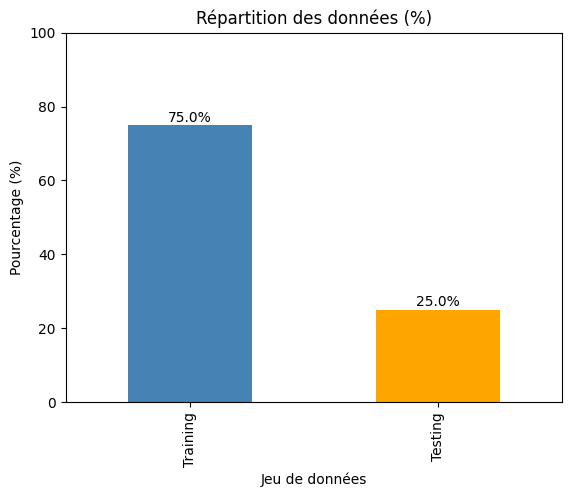

In [7]:
split_data.plot_data_split(train_data, test_data)

### d) Graphique de la répartition des données par LABEL

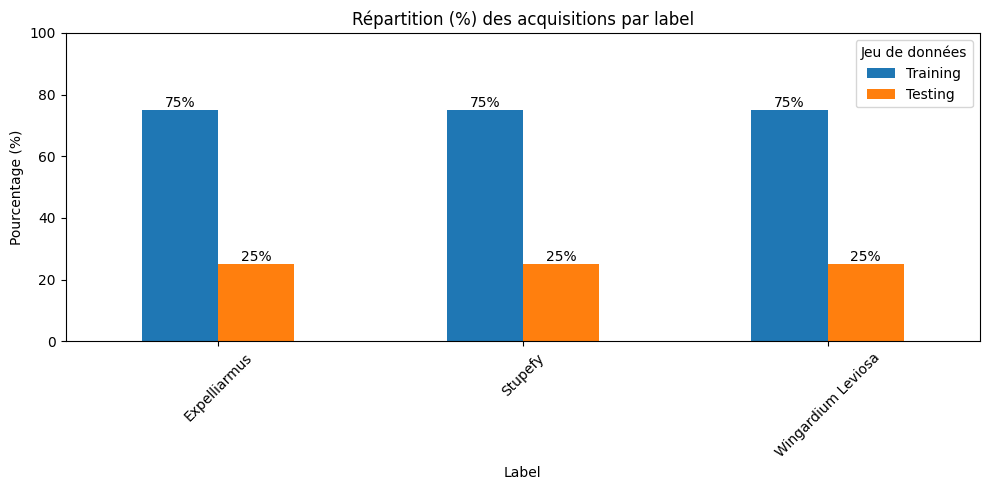

In [8]:
split_data.plot_label_split(train_data, test_data)

### e) Questions

1) Faire le split avec un pourcentage de 25% de données de test, donnez ensuite le nombre de lignes des données de test (valeur)
4) Pourquoi mélanger les données avant le split ? (Questions à choix multiples)
5) Pourquoi est-il important d'avoir des données que le modèle n'a jamais vu? (Questions à choix multiples)
6) Le jeu de test doit servir à entraîner le modèle (vrai ou faux)
8) Si on possède 300 acquisitions et que l'on a un split de 80/20, combien d'acquisitions sont utilisées pour l'entraînement ? (valeur)
9) Training--> apprentissage; validation --> réglage des hyperparamètres; test--> évaluation finale (association)

## 3. Analyse spectrale

Dans cette section, nous allons réaliser **l'analyse spectrale** d'une donnée en particulier. Nous allons d'abord observer son **image temporelle** pour ensuite l'analyser grâce à une **transformée de Fourier rapide (FFT)**. Cela nous permettra ensuite de générer des caractéristiques (**features**) pour toutes les données que l'on pourra utiliser pour entraîner et tester le modèle.


### a) Importation des bibliothèques nécessaires

In [9]:
import numpy as np
import matplotlib.pyplot as plt

### b) Image temporelle de la donnée brute

In [10]:
#Choix d'une fonction à analyser

def choisir_acquisition(dataset, label, numero):
    """
    Sélectionne une acquisition d'un label.

    Paramètres
    ----------
    dataset : train_data ou test_data
    label : nom du label
    numero : indice de l'acquisition (0 = première, 1 = deuxième, ...)
    """

    acquisitions = (
        dataset[dataset["label"] == label]["source_file"]
        .drop_duplicates()
        .tolist()
    )

    sample_file = acquisitions[numero]
    sample = dataset[dataset["source_file"] == sample_file]

    return sample


# Exemple
sample = choisir_acquisition(train_data, "Wingardium Leviosa", 2)

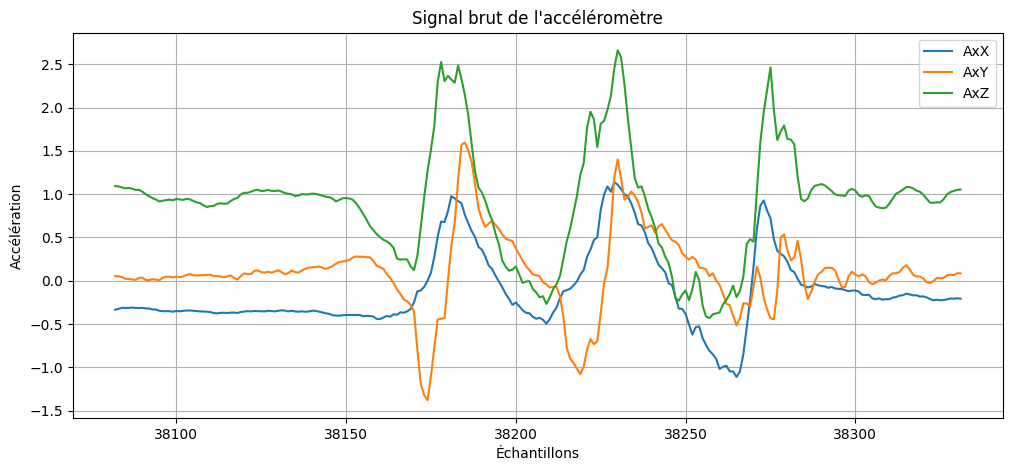

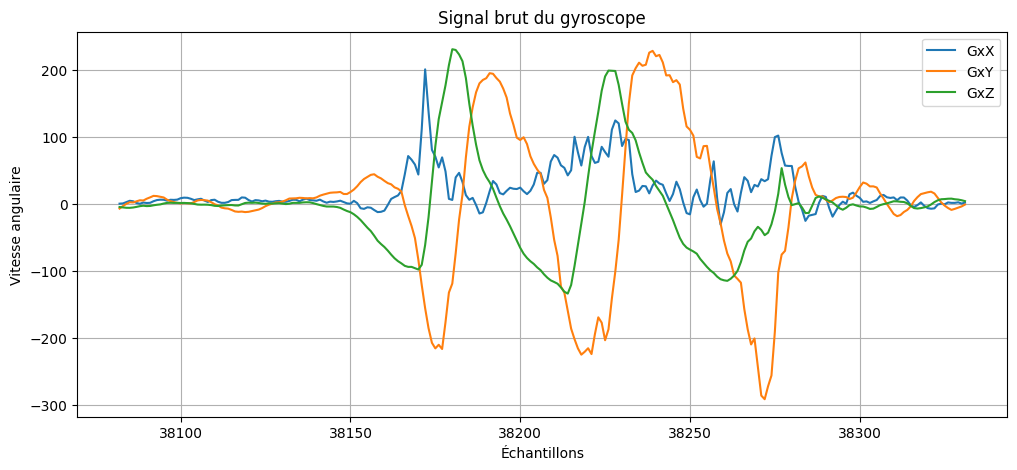

In [11]:
# Image en temporel de la donnée brute (accéléromètre)

plt.figure(figsize=(12, 5))

plt.plot(sample["AxX"], label="AxX")
plt.plot(sample["AxY"], label="AxY")
plt.plot(sample["AxZ"], label="AxZ")

plt.title("Signal brut de l'accéléromètre")
plt.xlabel("Échantillons")
plt.ylabel("Accélération")
plt.legend()
plt.grid(True)

plt.show()

# Image en temporel de la donnée brute (gyroscope)

plt.figure(figsize=(12, 5))

plt.plot(sample["GxX"], label="GxX")
plt.plot(sample["GxY"], label="GxY")
plt.plot(sample["GxZ"], label="GxZ")

plt.title("Signal brut du gyroscope")
plt.xlabel("Échantillons")
plt.ylabel("Vitesse angulaire")
plt.legend()
plt.grid(True)

plt.show()

### c) Analyse spectrale de la donnée

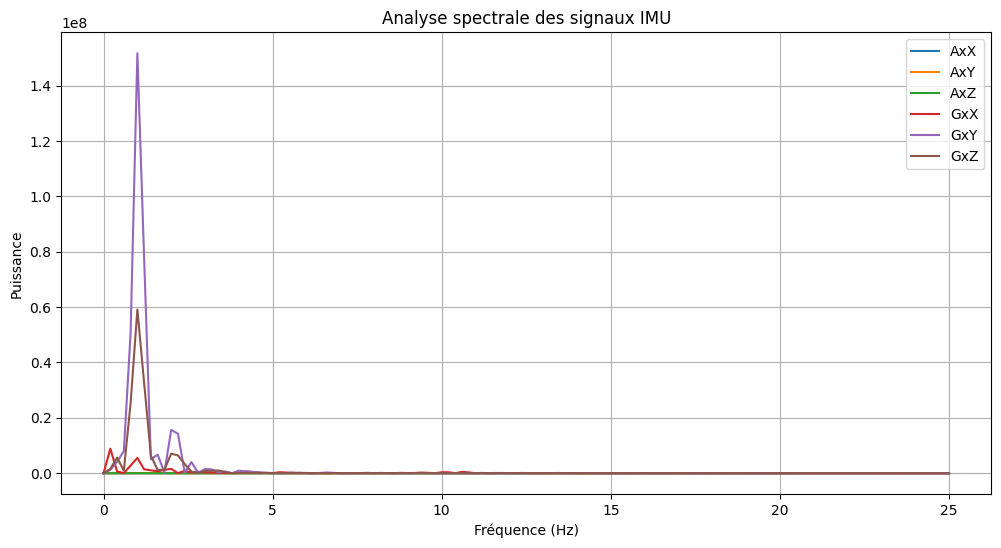

In [12]:
# Analyse spectrale (FFT)

# Fréquence d'échantillonnage
interval_ms = 20          # 20 ms si la XIAO échantillonne à 50 Hz (delay(20))
fs = 1000 / interval_ms

axes = ["AxX", "AxY", "AxZ", "GxX", "GxY", "GxZ"]

plt.figure(figsize=(12, 6))

# Application de la FFT sur chaque axe
for axis in axes:

    signal = sample[axis].values

    # Suppression de la composante continue
    signal = signal - np.mean(signal)

    fft_values = np.fft.rfft(signal)
    power = np.abs(fft_values) ** 2
    fft_freqs = np.fft.rfftfreq(len(signal), d=1/fs)

    plt.plot(fft_freqs, power, label=axis)

plt.title("Analyse spectrale des signaux IMU")
plt.xlabel("Fréquence (Hz)")
plt.ylabel("Puissance")
plt.legend()
plt.grid(True)

plt.show()

### d) Questions

1) Pourquoi il est préférable de faire une analyse fréquentielle plutot qu'une analyse temporelle dans ce cas de figure? (Questions à choix multiples)
2) Quel type de filtre appliqueriez vous en observant l'analyse spectrale du signal Expelliarmus numéro 0? (choix unique) 
3) Determinez l'intervalle de temps "intervalle_ms" pour avoir la bonne fréquence d'échantillonage correspondant à la carte Seeed Xiao NRF52840 sense.
4) Afficher l'analyse spectrale?
6) Sur le sort "Wingardium Leviosa" de numéro 2, quel est l'axe de l'IMU prédominant vers 2Hz? (choix unique)
7) Comment le bruit influence-t-il le spectre fréquentiel ? (questions à choix mutliples)

## 4. Pré-traitement des données et génération de features

Ici, nous allons réaliser le **pré-traitement des données** avant l'entraînement du modèle:
* Nous allons d'abord réaliser un **split des données d'entraînement** en 2: celles qui vont servir à entraîner le modèle (**training set**) et celles qui vont servir à le valider (**validation set**).
* Ensuite, nous allons réaliser l'analyse spectrale de toutes les données pour permettre la **génération de caractéristiques** (features) qui vont servir pour l'entraînement et le test.
* Nous allons également réaliser quelques traitements sur les features avant leur utilisation.

### a) Importation des bibliothèques nécessaires

In [13]:
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis
from sklearn.preprocessing import StandardScaler, LabelEncoder

### b) Split train/validation

In [14]:
#Fonction qui réalise le split train/validation

def split_train_validation(train_data, validation_size=0.2, random_state=42):
    """
    Sépare le jeu d'entraînement en un jeu d'entraînement et un jeu de validation.

    Le découpage est effectué par acquisition (source_file) afin qu'une
    acquisition complète appartienne soit au jeu d'entraînement, soit au
    jeu de validation. La proportion est respectée pour chaque label.

    Paramètres
    ----------
    train_data : DataFrame
        Jeu d'entraînement.
    validation_size : float
        Proportion des acquisitions à placer dans le jeu de validation.
    random_state : int
        Graine aléatoire.

    Retour
    ------
    train_final, validation_data
    """

    train_files = []
    validation_files = []

    # Découpage indépendant pour chaque label
    for label in train_data["label"].unique():

        acquisitions = (
            train_data[train_data["label"] == label]["source_file"]
            .drop_duplicates()
            .tolist()
        )

        train, validation = train_test_split(
            acquisitions,
            test_size=validation_size,
            random_state=random_state,
            shuffle=True
        )

        train_files.extend(train)
        validation_files.extend(validation)

    train_final = train_data[
        train_data["source_file"].isin(train_files)
    ].reset_index(drop=True)

    validation_data = train_data[
        train_data["source_file"].isin(validation_files)
    ].reset_index(drop=True)

    print(f"Pourcentage de validation demandé : {validation_size*100:.0f}%")
    print(f"Nombre de lignes entraînement : {len(train_final)}")
    print(f"Nombre de lignes validation : {len(validation_data)}")

    print("\nRépartition par label :")
    repartition = pd.DataFrame({
        "Training": train_final.groupby("label")["source_file"].nunique(),
        "Validation": validation_data.groupby("label")["source_file"].nunique()
    }).fillna(0).astype(int)

    repartition["Total"] = (
        repartition["Training"] + repartition["Validation"]
    )

    repartition["% Validation"] = (
        repartition["Validation"] / repartition["Total"] * 100
    ).round(1)

    display(repartition)

    return train_final, validation_data

# Deuxième découpage : Train / Validation
train_data, validation_data = split_train_validation(
    train_data,
    validation_size=0.2
)

Pourcentage de validation demandé : 20%
Nombre de lignes entraînement : 45101
Nombre de lignes validation : 11274

Répartition par label :


,Training,Validation,Total,% Validation
label,,,,
Expelliarmus,60,15,75,20.0
Stupefy,60,15,75,20.0
Wingardium Leviosa,60,15,75,20.0


### c) Génération des caractéristiques pour toutes les données

In [15]:
# Axes du capteur
axes = ["AxX", "AxY", "AxZ", "GxX", "GxY", "GxZ"]


#Fonction qui génère les caractéristiques d'une donnée par analyse spectrale

def generate_spectral_features(sample, axes=axes, n_fft=20):
    """
    Génère les caractéristiques statistiques et fréquentielles
    d'une acquisition.

    Paramètres
    ----------
    sample : DataFrame
        Acquisition à analyser.
    axes : list
        Liste des axes IMU.
    n_fft : int
        Nombre de coefficients FFT conservés.

    Retour
    ------
    dict
        Dictionnaire contenant les caractéristiques.
    """

    features = {}

    for axis in axes:

        signal = sample[axis].to_numpy(dtype=float)

        # Suppression de la composante continue
        signal = signal - np.mean(signal)

        # Caractéristiques statistiques
        features[f"{axis}_rms"] = np.sqrt(np.mean(signal**2))
        features[f"{axis}_skewness"] = skew(signal)
        features[f"{axis}_kurtosis"] = kurtosis(signal)

        # FFT
        fft_values = np.fft.rfft(signal)
        power = np.abs(fft_values) ** 2

        # On ignore fft_0 : la composante continue a déjà été retirée.
        # On conserve les coefficients 1 à 20.
        power = power[1:n_fft + 1]

        for i, value in enumerate(power):
            features[f"{axis}_fft_{i}"] = value

    return features

In [16]:
# 2. Fonction de génération des features pour toutes les données

def construire_features(dataset):
    feature_rows = []

    for source_file, sample in dataset.groupby("source_file"):
        features = generate_spectral_features(sample, axes, n_fft=20)

        features["source_file"] = source_file
        features["label"] = sample["label"].iloc[0]

        feature_rows.append(features)

    return pd.DataFrame(feature_rows)

In [17]:
# 3. Génération des features pour les trois jeux de données
features_train = construire_features(train_data)
features_validation = construire_features(validation_data)
features_test = construire_features(test_data)

X_train = features_train.drop(columns=["source_file", "label"])
y_train = features_train["label"]

X_validation = features_validation.drop(columns=["source_file", "label"])
y_validation = features_validation["label"]

X_test = features_test.drop(columns=["source_file", "label"])
y_test = features_test["label"]

### d) Codage et normalisation des features

Ici, avant l'entraînement du modèle, il est important de **coder et normaliser** les caractéristiques pour permettre un entraînement optimal et efficace.

In [18]:
#Codage et normalisation des features

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_validation_encoded = label_encoder.transform(y_validation)
y_test_encoded = label_encoder.transform(y_test)

print(label_encoder.classes_)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_validation_scaled = scaler.transform(X_validation)
X_test_scaled = scaler.transform(X_test)

['Expelliarmus' 'Stupefy' 'Wingardium Leviosa']


### e) Questions

1) Faire la génération des features pour les 3 jeux de données (partie à compléter)
2) Quelle est la différence entre les données de test et les données de validation? (choix unique)
3) Faire le split train/validation à 80/20, combien y-a-t-il de lignes pour les données de validation? (valeur)
5) Pourquoi est-il important de pré-traiter les données avant l'entraînement? (questions à choix multiples)
6) Pourquoi est-il important de normaliser les features? (choix unique)
7) Pourquoi faut-il coder les features avant l'entraînement? (choix unique)
9) Associez chacune de ses méthodes à leur definitions: Hold-Out, K-Fold et Leave-One-Out (association)

## 5. Classification sur données d'entraînement

Nous passons maintenant à la partie de l'**entraînement du modèle** avec **un réseau de neurones**, grâce aux données d'entraînement. 

<img src="https://raw.githubusercontent.com/adarshbk12/Stage_IA/master/reseau_neurones.png"
     alt="Réseau de neurones"
     width="600">

Cela nous permettra ensuite d'observer les **performances du modèle** (métriques, matrice de confusion) avec les données de validation qui serviront à régler le modèle et l'ajuster.

### a) Importation des bibliothèques nécessaires

In [19]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt

### b) Création du réseau de neurones et compilation du modèle

In [20]:
#Architecture du réseau de neurones

num_features = X_train_scaled.shape[1]
num_classes = len(label_encoder.classes_)

model = Sequential([
    Dense(64, activation="relu", input_shape=(num_features,)),
    Dropout(0.3),

    Dense(32, activation="relu"),
    Dropout(0.3),

    Dense(num_classes, activation="softmax")
])

C:\Program Files\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### c) Compilation du modèle

In [21]:
# Compilation du modèle

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

### d) Entraînement du modèle

In [22]:
#Entraînement 

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled,
    y_train_encoded,
    validation_data=(X_validation_scaled, y_validation_encoded),
    epochs=10,
    batch_size=16,
    callbacks=[early_stop]
)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.4778 - loss: 1.1066 - val_accuracy: 0.9333 - val_loss: 0.4590
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8833 - loss: 0.4332 - val_accuracy: 1.0000 - val_loss: 0.1486
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9556 - loss: 0.1806 - val_accuracy: 1.0000 - val_loss: 0.0573
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9778 - loss: 0.0983 - val_accuracy: 1.0000 - val_loss: 0.0270
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9667 - loss: 0.1360 - val_accuracy: 1.0000 - val_loss: 0.0152
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9667 - loss: 0.0845 - val_accuracy: 1.0000 - val_loss: 0.0098
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9944 - loss: 0.0495 - val_accuracy: 1.0000 - val_loss: 0.0068
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9944 - loss: 0.0357 - val_accuracy: 1.0000 - val_loss

### d) Performances de l'entraînement

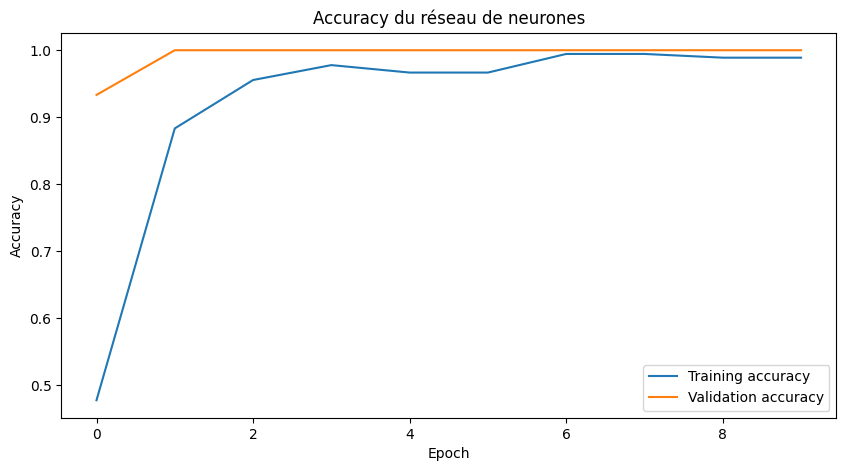

In [23]:
#Graphique de l'accuracy

plt.figure(figsize=(10, 5))

plt.plot(history.history["accuracy"], label="Training accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")

plt.title("Accuracy du réseau de neurones")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

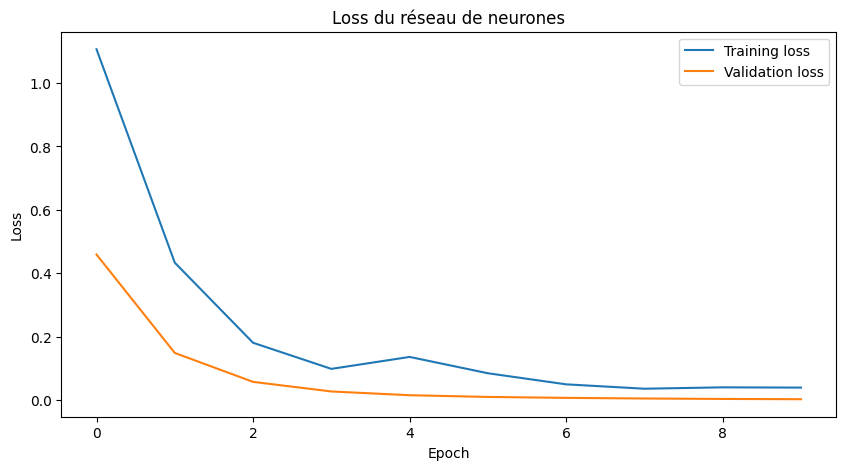

In [24]:
#Graphique de la fonction de perte du modèle

plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")

plt.title("Loss du réseau de neurones")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [25]:
#Métriques

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
import pandas as pd
import numpy as np

# Prédictions sur le jeu de validation
y_validation_proba = model.predict(X_validation_scaled)
y_validation_pred = np.argmax(y_validation_proba, axis=1)

# Calcul des métriques
metrics = pd.DataFrame({
    "Metric": [
        "Area under ROC Curve",
        "Weighted average Precision",
        "Weighted average Recall",
        "Weighted average F1 score"
    ],
    "Value": [
        roc_auc_score(
            y_validation_encoded,
            y_validation_proba,
            multi_class="ovr",
            average="weighted"
        ),
        precision_score(
            y_validation_encoded,
            y_validation_pred,
            average="weighted",
            zero_division=0
        ),
        recall_score(
            y_validation_encoded,
            y_validation_pred,
            average="weighted",
            zero_division=0
        ),
        f1_score(
            y_validation_encoded,
            y_validation_pred,
            average="weighted",
            zero_division=0
        )
    ]
})

metrics["Value"] = metrics["Value"].map(lambda x: f"{x:.2f}")

display(metrics)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


,Metric,Value
0,Area under ROC Curve,1.00
1,Weighted average Precision,1.00
2,Weighted average Recall,1.00
3,Weighted average F1 score,1.00


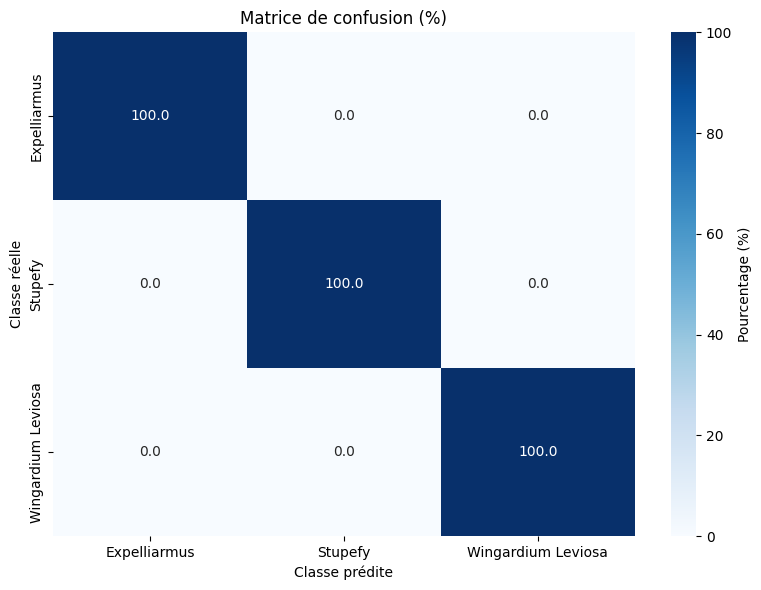

In [26]:
#Matrice de confusion

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def afficher_matrice_confusion(y_true, y_pred, labels):
    """
    Affiche une matrice de confusion normalisée en pourcentage.

    Paramètres
    ----------
    y_true : array
        Labels réels (encodés).
    y_pred : array
        Labels prédits (encodés).
    labels : list
        Liste des noms des classes.
    """

    # Matrice de confusion
    cm = confusion_matrix(y_true, y_pred)

    # Normalisation par ligne (classe réelle)
    cm_percent = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    plt.figure(figsize=(8, 6))

    sns.heatmap(
        cm_percent,
        annot=True,
        fmt=".1f",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        vmin=0,
        vmax=100,
        cbar_kws={"label": "Pourcentage (%)"}
    )

    plt.xlabel("Classe prédite")
    plt.ylabel("Classe réelle")
    plt.title("Matrice de confusion (%)")

    plt.tight_layout()
    plt.show()

afficher_matrice_confusion(
    y_validation_encoded,
    y_validation_pred,
    label_encoder.classes_
)

### e) Questions

1) Combien de couches contient le réseau? Analysez l'architecture du réseau de neurone. (valeur)
2) Quelle est la fonction d'activation utilisée pour la sortie du réseau de neurone? (Réponse rédigée)
3) Compilez et entraînez le modèle. Sur quoi le nombre d'époques a une/des conséquence(s)? (choix multiples)
4) Afficher l'accuracy/fonction de perte de la validation en suivant l'exemple de celles de l'entraînement.
5) Associez chaque métriques à sa définition (association)
6) Afficher la matrice de confusion.
7) Calculez l'accuracy du modèle grâce à la matrice de confusion avec epochs=2à (valeur)
8) Comment obtenir la probabilité de détection et le ratio de faux positifs avec la matrice de confusion? (choix unique)
9) Quel est le rôle de la fonction d'activation ? (choix unique)
10) Comment détecter un surapprentissage à partir des courbes d'entraînement et de validation ? (choix mutliples)

## 6. Test du modèle

Pour cette dernière étape avant le déploiement embarqué sur carte du modèle, nous allons **tester le modèle** avec les données qu'il n'a jamais vu, les **données de test**. Ce test permettra d'avoir les **performances réelles du modèle** quand on lui présente de nouvelles données qui ne lui ont pas servi pour s'entraîner.

### a) Codage et normalisation des features

Ici, avant le test du modèle, il est important de **coder et normaliser** les caractéristiques pour permettre un test optimal et efficace.

In [27]:
# Données de test

X_test = features_test.drop(
    columns=["source_file", "label"]
)

y_test = features_test["label"]

# Encodage des labels
y_test_encoded = label_encoder.transform(y_test)

# Normalisation des caractéristiques
X_test_scaled = scaler.transform(X_test)

### b) Prédicition du modèle sur les données de test

In [28]:
# Prédictions sur le jeu de test
y_test_proba = model.predict(X_test_scaled)
y_test_pred = np.argmax(y_test_proba, axis=1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


### c) Performance du modèle

In [29]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
import pandas as pd

# Calcul des métriques
test_metrics = pd.DataFrame({
    "Metric": [
        "Area under ROC Curve",
        "Weighted average Precision",
        "Weighted average Recall",
        "Weighted average F1 score"
    ],
    "Value": [
        roc_auc_score(
            y_test_encoded,
            y_test_proba,
            multi_class="ovr",
            average="weighted"
        ),
        precision_score(
            y_test_encoded,
            y_test_pred,
            average="weighted",
            zero_division=0
        ),
        recall_score(
            y_test_encoded,
            y_test_pred,
            average="weighted",
            zero_division=0
        ),
        f1_score(
            y_test_encoded,
            y_test_pred,
            average="weighted",
            zero_division=0
        )
    ]
})

test_metrics["Value"] = test_metrics["Value"].map(lambda x: f"{x:.2f}")

display(test_metrics.style.hide(axis="index"))

Metric,Value
Area under ROC Curve,1.00
Weighted average Precision,1.00
Weighted average Recall,1.00
Weighted average F1 score,1.00


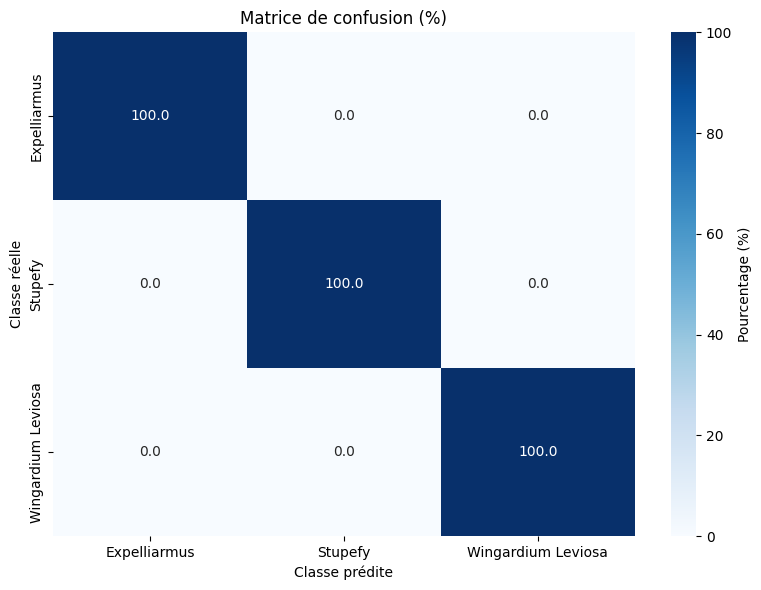

In [30]:
#Matrice de confusion

afficher_matrice_confusion(
    y_test_encoded,
    y_test_pred,
    label_encoder.classes_
)

### d) Questions

1) Afficher la matrice de confusion et les métriques.
3) Analysez la matrice de confusion: Sur quels labels faut-il jouer pour améliorer la performance du modèle? (questions à choix multiples)
4) Pourquoi l'accuracy du test est-elle plus basse que celle de la validation lors de l'entraînement? (choix unique)
5) Que représentent les faux positifs? et les faux négatifs ? (choix unique)
6) Une accuracy de 100% garantit un modèle parfaitement fiable (vrai ou faux)

## **PARTIE 2: Déploiement du modèle sur la carte Seeed XIAO nRF52840 Sense**

Nous allons embarquer le réseau de neurones sur la carte Seeed Xiao NRF52840 Sense. Le notebook **exporte simplement les poids et les biais appris dans un fichier C++** (`model_params.h`). Sur la carte, une fonction C++ calcule directement les couches denses, les activations ReLU puis le softmax.

Le déroulement ensuite pour l'acquisition directe sur la carte est le suivant :

1. acquisition de mesures IMU à 50 Hz (fenêtre de 5 s) ;
2. calcul des mêmes caractéristiques que pendant l'entraînement ;
3. normalisation avec les paramètres du `StandardScaler` ;
4. inférence C++ : couche dense 138→32, ReLU, couche dense 32→16, ReLU, couche dense 16→classes, softmax ;
5. affichage de la classe et clignotement de la LED.

**Voici les étapes à suivre**: 
* Branchez la carte de la baguette magique à l'ordinateur via le cable USB
* IL EST IMPORTANT QUE L'ALIMENTATION SOIT EN MODE OFF
* Réalisez ensuite les étapes qui suivent pour charger le modèle sur la carte et le tester sans le branchement à l'ordinateur

### a) Présentation de la carte Seeed Xiao NRF52840 sense

<img src="https://raw.githubusercontent.com/adarshbk12/Stage_IA/master/Seeed-Studio-XIAO-nRF52840-Sense.jpg" width="300">

La carte **Seeed Xiao NRF52840 sense** est équipée d'un **IMU** (Inertial Measurement Unit), qui renvoie les données d'un **gyroscope** (sur 3 axes) et d'un **accéléromètre** (sur 3 axes), cela nous permettra d'analyser les gestes réalisées.

Nous allons donc charger le modèle que nous avons entraîné sur cette carte, nous allons ensuite dans la PARTIE 3 enregistrer de nouvelles données grâce à celle-ci.

### b) Installation du support de la carte Seeed Xiao NRF52840 Sense

In [31]:
import subprocess

import os
import shutil
from pathlib import Path

def trouver_arduino_cli():
    # 1. Chemin éventuellement défini par l'élève
    chemin_configure = os.environ.get("ARDUINO_CLI")

    if chemin_configure and Path(chemin_configure).is_file():
        return chemin_configure

    # 2. Recherche dans le PATH du système
    chemin_path = shutil.which("arduino-cli")

    if chemin_path:
        return chemin_path

    # 3. Recherche à côté du notebook
    noms_possibles = [
        "arduino-cli.exe",  # Windows
        "arduino-cli",      # Linux et macOS
    ]

    for nom in noms_possibles:
        candidat = Path.cwd() / nom

        if candidat.is_file():
            return str(candidat.resolve())

    raise FileNotFoundError(
        "arduino-cli est introuvable.\n"
        "Installez Arduino CLI et ajoutez-le au PATH, ou placez "
        "arduino-cli.exe dans le même dossier que le notebook."
    )


ARDUINO_CLI = trouver_arduino_cli()

print("Arduino CLI détecté :", ARDUINO_CLI)

SEEED_INDEX = (
    "https://files.seeedstudio.com/arduino/"
    "package_seeeduino_boards_index.json"
)

def executer_commande(command):
    print("\n>", subprocess.list2cmdline(command))

    result = subprocess.run(
        command,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        errors="replace",
    )

    print(result.stdout)

    if result.returncode != 0:
        raise RuntimeError(
            f"Commande échouée avec le code {result.returncode}"
        )

# 1. Téléchargement de l’index officiel Seeed Studio
executer_commande([
    ARDUINO_CLI,
    "core",
    "update-index",
    "--additional-urls",
    SEEED_INDEX,
])

# 2. Installation du cœur utilisé par le FQBN du notebook
executer_commande([
    ARDUINO_CLI,
    "core",
    "install",
    "Seeeduino:nrf52",
    "--additional-urls",
    SEEED_INDEX,
])

# 3. Vérification
executer_commande([
    ARDUINO_CLI,
    "core",
    "list",
])

print("Support de la XIAO nRF52840 installé.")

Arduino CLI détecté : .\arduino-cli.EXE

> .\arduino-cli.EXE core update-index --additional-urls https://files.seeedstudio.com/arduino/package_seeeduino_boards_index.json




> .\arduino-cli.EXE core install Seeeduino:nrf52 --additional-urls https://files.seeedstudio.com/arduino/package_seeeduino_boards_index.json
Platform Seeeduino:nrf52@1.1.13 already installed


> .\arduino-cli.EXE core list
ID              InstallÃ© Latest Name
Seeeduino:nrf52 1.1.13   1.1.13 Seeed nRF52 Boards


Support de la XIAO nRF52840 installé.


### c) Installation des bibliothèques Arduino nécessaires

In [32]:
import subprocess

ARDUINO_CLI = trouver_arduino_cli()

install_command = [
    ARDUINO_CLI,
    "lib",
    "install",
    "Seeed Arduino LSM6DS3",
]

print("Commande exécutée :")
print(subprocess.list2cmdline(install_command))

install_result = subprocess.run(
    install_command,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    errors="replace",
)

print(install_result.stdout)

if install_result.returncode != 0:
    raise RuntimeError("Échec de l’installation de la bibliothèque LSM6DS3")

print("Bibliothèque LSM6DS3 installée.")

Commande exécutée :
.\arduino-cli.EXE lib install "Seeed Arduino LSM6DS3"
DÃ©jÃ  installÃ© Seeed Arduino LSM6DS3@2.0.7

Bibliothèque LSM6DS3 installée.


### d) Export des paramètres du modèle

In [33]:
import numpy as np
from pathlib import Path


def exporter_modele_cpp(
    model,
    scaler,
    label_encoder,
    fichier_sortie="model_params.h",
):
    """
    Exporte un réseau Keras à trois couches Dense vers un fichier C++.

    Paramètres
    ----------
    model : modèle Keras entraîné
    scaler : StandardScaler entraîné
    label_encoder : LabelEncoder entraîné
    fichier_sortie : nom ou chemin du fichier .h à générer

    Retour
    ------
    Path
        Chemin absolu du fichier généré.
    """

    # --------------------------------------------------------
    # Conversion d'une valeur en littéral float C++ valide
    # --------------------------------------------------------

    def cpp_float(value):
        value = float(value)

        if not np.isfinite(value):
            raise ValueError(
                "Un paramètre du modèle contient NaN "
                "ou une valeur infinie."
            )

        text = f"{value:.9g}"

        # 818421f est invalide en C++ : il faut 818421.0f.
        if "." not in text and "e" not in text.lower():
            text += ".0"

        return text + "f"

    # --------------------------------------------------------
    # Écriture d'un tableau C++
    # --------------------------------------------------------

    def write_float_array(file, name, array, per_line=8):
        values = np.asarray(
            array,
            dtype=np.float32,
        ).ravel(order="C")

        file.write(
            f"const float {name}[{len(values)}] = {{\n"
        )

        for start in range(0, len(values), per_line):
            end = start + per_line

            row = ", ".join(
                cpp_float(value)
                for value in values[start:end]
            )

            file.write("  " + row)

            if end < len(values):
                file.write(",")

            file.write("\n")

        file.write("};\n\n")

    # --------------------------------------------------------
    # Vérification des objets
    # --------------------------------------------------------

    if not hasattr(model, "layers"):
        raise TypeError(
            "'model' ne contient pas un modèle Keras valide."
        )

    if not hasattr(scaler, "mean_"):
        raise TypeError(
            "'scaler' ne contient pas un StandardScaler entraîné."
        )

    if not hasattr(scaler, "scale_"):
        raise TypeError(
            "'scaler' ne contient pas un StandardScaler entraîné."
        )

    if not hasattr(label_encoder, "classes_"):
        raise TypeError(
            "'label_encoder' ne contient pas un "
            "LabelEncoder entraîné."
        )

    # --------------------------------------------------------
    # Récupération des couches Dense
    # --------------------------------------------------------

    # Les couches Dropout n'ont aucun rôle pendant l'inférence.
    dense_layers = [
        layer
        for layer in model.layers
        if len(layer.get_weights()) == 2
    ]

    if len(dense_layers) != 3:
        raise ValueError(
            "La fonction attend exactement trois couches Dense.\n"
            f"Nombre de couches trouvé : {len(dense_layers)}"
        )

    (w1, b1), (w2, b2), (w3, b3) = [
        layer.get_weights()
        for layer in dense_layers
    ]

    labels = [
        str(label)
        for label in label_encoder.classes_
    ]

    # --------------------------------------------------------
    # Vérification des dimensions
    # --------------------------------------------------------

    if w1.shape[0] != len(scaler.mean_):
        raise ValueError(
            "Le nombre d'entrées du modèle ne correspond pas "
            "au nombre de features du scaler.\n"
            f"Entrées du modèle : {w1.shape[0]}\n"
            f"Features du scaler : {len(scaler.mean_)}"
        )

    if len(scaler.mean_) != len(scaler.scale_):
        raise ValueError(
            "Les tableaux mean_ et scale_ du scaler "
            "n'ont pas la même longueur."
        )

    if w1.shape[1] != w2.shape[0]:
        raise ValueError(
            "Les dimensions des couches Dense 1 et 2 "
            "sont incompatibles."
        )

    if w2.shape[1] != w3.shape[0]:
        raise ValueError(
            "Les dimensions des couches Dense 2 et 3 "
            "sont incompatibles."
        )

    if w3.shape[1] != len(labels):
        raise ValueError(
            "Le nombre de sorties du modèle ne correspond pas "
            "au nombre de labels."
        )

    # --------------------------------------------------------
    # Génération du fichier model_params.h
    # --------------------------------------------------------

    header_path = Path(fichier_sortie)

    with header_path.open(
        "w",
        encoding="utf-8",
        newline="\n",
    ) as file:

        file.write(
            "#ifndef MODEL_PARAMS_H\n"
            "#define MODEL_PARAMS_H\n\n"
        )

        file.write("#include <Arduino.h>\n\n")

        file.write(
            f"constexpr int N_FEATURES = {w1.shape[0]};\n"
        )

        file.write(
            f"constexpr int N_HIDDEN_1 = {w1.shape[1]};\n"
        )

        file.write(
            f"constexpr int N_HIDDEN_2 = {w2.shape[1]};\n"
        )

        file.write(
            f"constexpr int N_CLASSES = {w3.shape[1]};\n\n"
        )

        write_float_array(
            file,
            "SCALER_MEAN",
            scaler.mean_,
        )

        write_float_array(
            file,
            "SCALER_SCALE",
            scaler.scale_,
        )

        # Matrices Keras : ordre [entrée, sortie].
        write_float_array(file, "MODEL_W1", w1)
        write_float_array(file, "MODEL_B1", b1)

        write_float_array(file, "MODEL_W2", w2)
        write_float_array(file, "MODEL_B2", b2)

        write_float_array(file, "MODEL_W3", w3)
        write_float_array(file, "MODEL_B3", b3)

        escaped_labels = [
            label
            .replace("\\", "\\\\")
            .replace('"', '\\"')
            for label in labels
        ]

        file.write(
            "const char* const LABELS[N_CLASSES] = {\n  "
        )

        file.write(
            ", ".join(
                f'"{label}"'
                for label in escaped_labels
            )
        )

        file.write("\n};\n\n")
        file.write("#endif\n")

    # --------------------------------------------------------
    # Affichage du résumé
    # --------------------------------------------------------

    parameter_count = sum(
        weights.size + bias.size
        for weights, bias in [
            (w1, b1),
            (w2, b2),
            (w3, b3),
        ]
    )

    header_path = header_path.resolve()

    print(f"Fichier généré : {header_path}")

    print(
        "Architecture : "
        f"{w1.shape[0]} -> "
        f"{w1.shape[1]} -> "
        f"{w2.shape[1]} -> "
        f"{w3.shape[1]}"
    )

    print("Labels :", labels)
    print(f"Paramètres exportés : {parameter_count}")

    print(
        "Mémoire approximative des poids en float32 : "
        f"{4 * parameter_count / 1024:.1f} Kio"
    )

    return header_path

exporter_modele_cpp(
    model,
    scaler,
    label_encoder,
)

Fichier généré : \\netapp2\bassant-koum\Stage IA\Jupyter notebook\Sujet TP\model_params.h
Architecture : 138 -> 64 -> 32 -> 3
Labels : ['Expelliarmus', 'Stupefy', 'Wingardium Leviosa']
Paramètres exportés : 11075
Mémoire approximative des poids en float32 : 43.3 Kio


WindowsPath('//netapp2/bassant-koum/Stage IA/Jupyter notebook/Sujet TP/model_params.h')

### e) Déploiement du modèle sur carte

Ici, nous allons générer un **code Arduino contenant le modèle** qui sera implémenté sur la carte.

In [34]:
# ============================================================
# Génération, compilation et téléversement du sketch Arduino
# Inference directe en C++ : Dense + ReLU + Softmax
# ============================================================

import os
import time
import shutil
import subprocess
import serial
from serial.tools import list_ports

def trouver_port_xiao():
    """
    Recherche automatiquement une Seeed XIAO nRF52840 connectée.

    Retourne par exemple "COM10" sous Windows ou
    "/dev/ttyACM0" sous Linux.
    """

    ports_detectes = list(list_ports.comports())
    candidats = []

    for port in ports_detectes:
        description = (
            f"{port.description} "
            f"{port.manufacturer} "
            f"{port.product}"
        ).lower()

        # VID USB utilisé par Seeed Studio.
        est_seeed = port.vid == 0x2886

        # Recherche complémentaire par le nom du périphérique.
        est_xiao = any(
            mot in description
            for mot in [
                "xiao",
                "nrf52840",
                "seeed",
            ]
        )

        if est_seeed or est_xiao:
            candidats.append(port)

    if len(candidats) == 1:
        port = candidats[0]

        print(
            "Carte détectée :",
            port.device,
            "-",
            port.description,
        )

        return port.device

    if len(candidats) > 1:
        liste = "\n".join(
            f"  - {port.device} : {port.description}"
            for port in candidats
        )

        raise RuntimeError(
            "Plusieurs cartes Seeed/XIAO ont été détectées :\n"
            f"{liste}\n"
            "Débranchez les cartes qui ne sont pas utilisées."
        )

    ports_disponibles = "\n".join(
        f"  - {port.device} : {port.description}"
        for port in ports_detectes
    )

    if not ports_disponibles:
        ports_disponibles = "  Aucun port série détecté."

    raise RuntimeError(
        "Aucune Seeed XIAO nRF52840 n'a été détectée.\n"
        "Vérifiez le câble USB et le pilote de la carte.\n\n"
        "Ports série disponibles :\n"
        f"{ports_disponibles}"
    )


def attendre_port_xiao(timeout=15):
    """
    Attend que la carte réapparaisse après le téléversement.
    """

    debut = time.time()
    derniere_erreur = None

    while time.time() - debut < timeout:
        try:
            return trouver_port_xiao()
        except RuntimeError as erreur:
            derniere_erreur = erreur
            time.sleep(0.5)

    raise RuntimeError(
        "La carte n'est pas réapparue après le téléversement."
    ) from derniere_erreur

# À adapter à votre ordinateur
BAUDRATE = 115200
ARDUINO_CLI = trouver_arduino_cli()
PORT = trouver_port_xiao()
FQBN = "Seeeduino:nrf52:xiaonRF52840Sense"

SKETCH_NAME = "deploiement_xiao_cpp"
SKETCH_DIR = r"C:\temp\deploiement_xiao_cpp"

os.makedirs(SKETCH_DIR, exist_ok=True)
ino_path = os.path.join(SKETCH_DIR, SKETCH_NAME + ".ino")

arduino_code = r"""
#include <Arduino.h>
#include <Adafruit_TinyUSB.h>
#include <Wire.h>
#include <LSM6DS3.h>
#include <math.h>
#include "model_params.h"

LSM6DS3 imu(I2C_MODE, 0x6A);

constexpr int LED_D0 = D0;
constexpr int LED_D1 = D1;

constexpr int SAMPLE_RATE_HZ = 50;
constexpr int N_SAMPLES = 250;
constexpr int N_AXES = 6;
constexpr int N_FFT = 20;
constexpr uint32_t SERIAL_BAUDRATE = 115200;
constexpr uint32_t SAMPLE_PERIOD_US = 1000000UL / SAMPLE_RATE_HZ;
constexpr float EPSILON = 1.0e-12f;

float samples[N_SAMPLES][N_AXES];
float features[N_FEATURES];
float hidden1[N_HIDDEN_1];
float hidden2[N_HIDDEN_2];
float probabilities[N_CLASSES];

static_assert(N_FEATURES == N_AXES * (3 + N_FFT),
              "N_FEATURES ne correspond pas au calcul des features");

void acquireWindow();
void computeFeatures();
void normalizeFeatures();
void predictDirectCpp(const float* input, float* output);
void blinkLed(int count);
void setAllLeds(bool on);

void setup() {
  Serial.begin(SERIAL_BAUDRATE);
  // Ne pas bloquer la carte si elle fonctionne ensuite sans câble USB.
  const uint32_t serialStart = millis();
  while (!Serial && millis() - serialStart < 3000) {}

  pinMode(LED_BUILTIN, OUTPUT);
  pinMode(LED_D0, OUTPUT);
  pinMode(LED_D1, OUTPUT);

  // Toutes les LED sont éteintes au démarrage.
  setAllLeds(false);

  if (imu.begin() != 0) {
    Serial.println("Erreur : IMU non detectee");
    while (true) delay(1000);
  }
    Serial.println("XIAO prete - inference C++ directe.");
    Serial.println();
    Serial.println("Correspondance labels / clignotements :");

    for (int i = 0; i < N_CLASSES; ++i) {
      Serial.print("  ");
      Serial.print(LABELS[i]);
      Serial.print(" : ");
      Serial.print(i + 1);
      Serial.println((i + 1 == 1) ? " clignotement" : " clignotements");
    }

    Serial.println();
}

void loop() {
  Serial.println("Preparez le geste...");
  delay(1000);

  // Les trois LED restent allumées pendant l'acquisition.
  setAllLeds(true);
  acquireWindow();
  setAllLeds(false);

  computeFeatures();
  normalizeFeatures();
  predictDirectCpp(features, probabilities);

  int best = 0;
  for (int i = 1; i < N_CLASSES; ++i) {
    if (probabilities[i] > probabilities[best]) best = i;
  }

  const int blinkCount = best + 1;

  Serial.print("Sort reconnu : ");
  Serial.print(LABELS[best]);

  Serial.print(" | Score : ");
  Serial.print(probabilities[best], 4);

  Serial.print(" | Clignotements attendus : ");
  Serial.println(blinkCount);

  blinkLed(blinkCount);
  delay(2000);
}

void acquireWindow() {
  uint32_t nextSample = micros();
  for (int i = 0; i < N_SAMPLES; ++i) {
    samples[i][0] = imu.readFloatAccelX();
    samples[i][1] = imu.readFloatAccelY();
    samples[i][2] = imu.readFloatAccelZ();
    samples[i][3] = imu.readFloatGyroX();
    samples[i][4] = imu.readFloatGyroY();
    samples[i][5] = imu.readFloatGyroZ();

    nextSample += SAMPLE_PERIOD_US;
    while ((int32_t)(micros() - nextSample) < 0) {}
  }
}

void computeFeatures() {
  int featureIndex = 0;

  for (int axis = 0; axis < N_AXES; ++axis) {
    float mean = 0.0f;

    for (int n = 0; n < N_SAMPLES; ++n) {
      mean += samples[n][axis];
    }

    mean /= N_SAMPLES;

    float m2 = 0.0f;
    float m3 = 0.0f;
    float m4 = 0.0f;

    for (int n = 0; n < N_SAMPLES; ++n) {
      const float x = samples[n][axis] - mean;
      const float x2 = x * x;

      m2 += x2;
      m3 += x2 * x;
      m4 += x2 * x2;
    }

    m2 /= N_SAMPLES;
    m3 /= N_SAMPLES;
    m4 /= N_SAMPLES;

    // Caractéristiques statistiques
    features[featureIndex++] = sqrtf(m2);

    features[featureIndex++] =
        (m2 > EPSILON)
            ? m3 / powf(m2, 1.5f)
            : 0.0f;

    features[featureIndex++] =
        (m2 > EPSILON)
            ? m4 / (m2 * m2) - 3.0f
            : 0.0f;

    // Coefficients FFT 1 à 20.
    // k = 0 est ignoré car la composante continue a déjà été retirée.
    for (int k = 1; k <= N_FFT; ++k) {
      float re = 0.0f;
      float im = 0.0f;

      for (int n = 0; n < N_SAMPLES; ++n) {
        const float x = samples[n][axis] - mean;
        const float angle =
            -2.0f * PI * static_cast<float>(k * n)
            / static_cast<float>(N_SAMPLES);

        re += x * cosf(angle);
        im += x * sinf(angle);
      }

      features[featureIndex++] = re * re + im * im;
    }
  }
}

void normalizeFeatures() {
  for (int i = 0; i < N_FEATURES; ++i) {
    features[i] = (features[i] - SCALER_MEAN[i]) / SCALER_SCALE[i];
  }
}

void denseRelu(const float* input, int inputSize,
               const float* weights, const float* bias,
               float* output, int outputSize) {
  for (int j = 0; j < outputSize; ++j) {
    float sum = bias[j];
    for (int i = 0; i < inputSize; ++i) {
      // Matrices Keras exportées en ordre [entrée, sortie].
      sum += input[i] * weights[i * outputSize + j];
    }
    output[j] = (sum > 0.0f) ? sum : 0.0f;
  }
}

void denseLinear(const float* input, int inputSize,
                 const float* weights, const float* bias,
                 float* output, int outputSize) {
  for (int j = 0; j < outputSize; ++j) {
    float sum = bias[j];
    for (int i = 0; i < inputSize; ++i) {
      sum += input[i] * weights[i * outputSize + j];
    }
    output[j] = sum;
  }
}

void softmax(float* values, int size) {
  float maximum = values[0];
  for (int i = 1; i < size; ++i) maximum = max(maximum, values[i]);

  float total = 0.0f;
  for (int i = 0; i < size; ++i) {
    values[i] = expf(values[i] - maximum); // stabilisation numérique
    total += values[i];
  }
  if (total <= 0.0f) return;
  for (int i = 0; i < size; ++i) values[i] /= total;
}

void predictDirectCpp(const float* input, float* output) {
  denseRelu(
      input,
      N_FEATURES,
      MODEL_W1,
      MODEL_B1,
      hidden1,
      N_HIDDEN_1
  );

  denseRelu(
      hidden1,
      N_HIDDEN_1,
      MODEL_W2,
      MODEL_B2,
      hidden2,
      N_HIDDEN_2
  );

  denseLinear(
      hidden2,
      N_HIDDEN_2,
      MODEL_W3,
      MODEL_B3,
      output,
      N_CLASSES
  );

  softmax(output, N_CLASSES);
}

void setAllLeds(bool on) {
  // LED utilisateur : logique inversée.
  digitalWrite(
      LED_BUILTIN,
      on ? LOW : HIGH
  );

  // LED externes D0 et D1 : logique normale.
  digitalWrite(
      LED_D0,
      on ? HIGH : LOW
  );

  digitalWrite(
      LED_D1,
      on ? HIGH : LOW
  );
}

void blinkLed(int count) {
  for (int i = 0; i < count; ++i) {
    setAllLeds(true);
    delay(250);

    setAllLeds(false);
    delay(250);
  }
}
"""

if not os.path.exists("model_params.h"):
    raise FileNotFoundError("Exécutez d'abord la cellule qui génère model_params.h")

shutil.copy2("model_params.h", os.path.join(SKETCH_DIR, "model_params.h"))
with open(ino_path, "w", encoding="utf-8", newline="\n") as f:
    f.write(arduino_code)

print("Sketch généré :", ino_path)
print("Compilation en cours...")

compile_command = [
    ARDUINO_CLI,
    "compile",
    "--fqbn",
    FQBN,
    SKETCH_DIR,
]

compile_result = subprocess.run(
    compile_command,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    errors="replace",
)

if compile_result.returncode != 0:
    print("\n===== ERREUR DE COMPILATION =====\n")
    print(compile_result.stdout)
    print("\n===== FIN DE L'ERREUR =====\n")

    raise RuntimeError(
        f"Échec de la compilation Arduino "
        f"(code {compile_result.returncode})."
    )

print("Compilation réussie.")

print("Téléversement...")
upload_result = subprocess.run(
    [ARDUINO_CLI, "upload", "-p", PORT, "--fqbn", FQBN, SKETCH_DIR],
    capture_output=True, text=True
)
print(upload_result.stdout)
print(upload_result.stderr)
if upload_result.returncode != 0:
    raise RuntimeError("Échec du téléversement Arduino")

print("Téléversement terminé. Ouverture du moniteur série...")

# La carte peut disparaître puis revenir sur un autre port après son redémarrage.
PORT = attendre_port_xiao(timeout=15)

print("Port utilisé pour le moniteur série :", PORT)

ser = None
try:
    ser = serial.Serial(PORT, BAUDRATE, timeout=1)
    time.sleep(2)
    while True:
        line = ser.readline().decode("utf-8", errors="ignore").strip()
        if line:
            print(line)
except KeyboardInterrupt:
    print("Moniteur série arrêté.")
finally:
    if ser is not None and ser.is_open:
        ser.close()


Carte détectée : COM10 - Périphérique série USB (COM10)
Sketch généré : C:\temp\deploiement_xiao_cpp\deploiement_xiao_cpp.ino
Compilation en cours...
Compilation réussie.
Téléversement...
Upgrading target on COM9 with DFU package C:\Users\bassant-koum\AppData\Local\arduino\sketches\DC985BA50E9D451AC75E1C55D40CE02A\deploiement_xiao_cpp.ino.zip. Flow control is disabled, Single bank, Touch disabled
########################################
########################################
########################################
########################################
########################################
##
Activating new firmware
Device programmed.
New upload port: COM10 (serial)


Téléversement terminé. Ouverture du moniteur série...
Carte détectée : COM10 - Périphérique série USB (COM10)
Port utilisé pour le moniteur série : COM10
XIAO prete - inference C++ directe.
Correspondance labels / clignotements :
Expelliarmus : 1 clignotement
Stupefy : 2 clignotements
Wingardium Leviosa : 3 cligno

## **Testez maintenant le modèle en débranchant la carte et en allumant l'alimentation! (Faites des batailles de sort avec la baguette magique :))**

### f) Questions

1) Pourquoi on parle de modèle « embarqué » ? (choix multiples)
2) Quel contient le fichier `model_params.h`? (choix unique)
3) Le même pré-traitement doit être appliqué en Python et sur la carte (vrai ou faux)
8) Quelles contraintes de mémoire et de temps de calcul que l'on peut rencontrer? (questions à choix multiples)
9) Pourquoi la cadence réelle d'acquisition doit-elle rester proche de 50 Hz ? (questions à choix multiples)


## **PARTIE 3 : Ajouter un nouveau geste par fine-tuning**

Cette partie réalise toute la boucle d'amélioration du système :

1. remplacer temporairement le modèle embarqué par un firmware d'acquisition ;
2. enregistrer plusieurs exemples d'un nouveau label pendant 5 secondes à 50 Hz ;
3. adapter le modèle déjà entraîné en partie 1 sans repartir de poids aléatoires ;
4. exporter les nouveaux poids en C++ et ré-embarquer le modèle comme en partie 2.

Le fine-tuning réutilise le prétraitement, le `StandardScaler` et les couches cachées de la partie 1. La couche de sortie est agrandie afin d'ajouter le nouveau label. Les anciennes données sont mélangées aux nouvelles pour limiter l'oubli des sorts déjà connus.


## 1. Charger le firmware d'acquisition sur la carte

Le modèle de classification est temporairement remplacé par un programme simple. Lorsque Python envoie la commande `S`, la carte renvoie 250 mesures IMU, soit 5 secondes à 50 Hz, puis envoie `FIN`.

Les trois LED restent allumées pendant l'acquisition.


In [45]:
# Téléversement du firmware d'acquisition
import os
import time
import subprocess
from pathlib import Path

ARDUINO_CLI = trouver_arduino_cli()
PORT = trouver_port_xiao()
FQBN = "Seeeduino:nrf52:xiaonRF52840Sense"

ACQ_SKETCH_NAME = "acquisition_xiao"
ACQ_SKETCH_DIR = (
    Path("C:/temp/acquisition_xiao")
    if os.name == "nt"
    else Path("/tmp/acquisition_xiao")
)
ACQ_SKETCH_DIR.mkdir(parents=True, exist_ok=True)
ACQ_INO = ACQ_SKETCH_DIR / f"{ACQ_SKETCH_NAME}.ino"

acquisition_code = r"""
#include <Arduino.h>
#include <Adafruit_TinyUSB.h>
#include <Wire.h>
#include <LSM6DS3.h>

LSM6DS3 imu(I2C_MODE, 0x6A);

constexpr int LED_D0 = D0;
constexpr int LED_D1 = D1;
constexpr int SAMPLE_RATE_HZ = 50;
constexpr int N_SAMPLES = 250;
constexpr uint32_t SAMPLE_PERIOD_US = 1000000UL / SAMPLE_RATE_HZ;

void setAllLeds(bool on) {
  digitalWrite(LED_BUILTIN, on ? LOW : HIGH);
  digitalWrite(LED_D0, on ? HIGH : LOW);
  digitalWrite(LED_D1, on ? HIGH : LOW);
}

void setup() {
  Serial.begin(115200);
  const uint32_t start = millis();
  while (!Serial && millis() - start < 3000) {}

  pinMode(LED_BUILTIN, OUTPUT);
  pinMode(LED_D0, OUTPUT);
  pinMode(LED_D1, OUTPUT);
  setAllLeds(false);

  if (imu.begin() != 0) {
    Serial.println("ERREUR_IMU");
    while (true) delay(1000);
  }

  Serial.println("PRET");
}

void loop() {
  if (!Serial.available()) return;

  const char command = Serial.read();
  if (command != 'S') return;

  while (Serial.available()) Serial.read();
  setAllLeds(true);

  uint32_t nextSample = micros();
  for (int i = 0; i < N_SAMPLES; ++i) {
    Serial.print(imu.readFloatAccelX(), 8);
    Serial.print(',');
    Serial.print(imu.readFloatAccelY(), 8);
    Serial.print(',');
    Serial.print(imu.readFloatAccelZ(), 8);
    Serial.print(',');
    Serial.print(imu.readFloatGyroX(), 8);
    Serial.print(',');
    Serial.print(imu.readFloatGyroY(), 8);
    Serial.print(',');
    Serial.println(imu.readFloatGyroZ(), 8);

    nextSample += SAMPLE_PERIOD_US;
    while ((int32_t)(micros() - nextSample) < 0) {}
  }

  setAllLeds(false);
  Serial.println("FIN");
}
"""

ACQ_INO.write_text(acquisition_code, encoding="utf-8", newline="\n")

def commande_silencieuse(command, action):
    print(f"{action} en cours...")
    result = subprocess.run(
        command,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        errors="replace",
    )
    if result.returncode != 0:
        print(f"\n===== ERREUR : {action.upper()} =====\n")
        print(result.stdout)
        raise RuntimeError(f"{action} impossible (code {result.returncode}).")
    print(f"{action} réussi.")

commande_silencieuse(
    [ARDUINO_CLI, "compile", "--fqbn", FQBN, str(ACQ_SKETCH_DIR)],
    "Compilation du firmware d'acquisition",
)
commande_silencieuse(
    [ARDUINO_CLI, "upload", "-p", PORT, "--fqbn", FQBN, str(ACQ_SKETCH_DIR)],
    "Téléversement du firmware d'acquisition",
)

PORT = attendre_port_xiao(timeout=20)
print("Carte prête pour les acquisitions sur", PORT)


Carte détectée : COM10 - Périphérique série USB (COM10)
Compilation du firmware d'acquisition en cours...
Compilation du firmware d'acquisition réussi.
Téléversement du firmware d'acquisition en cours...
Téléversement du firmware d'acquisition réussi.
Carte détectée : COM10 - Périphérique série USB (COM10)
Carte prête pour les acquisitions sur COM10


## 2. Enregistrer le nouveau label

Choisissez **Créer un nouveau label**, puis enregistrez idéalement au moins 10 à 20 acquisitions. Réalisez toujours le même geste, avec des variations naturelles de vitesse, d'orientation et d'amplitude.


In [46]:
import time
import serial
import pandas as pd
from datetime import datetime

BAUDRATE = 115200
N_SAMPLES_ATTENDUS = 250
COLONNES_CAPTEURS = ["AxX", "AxY", "AxZ", "GxX", "GxY", "GxZ"]

def choisir_label():
    labels = sorted(data["label"].astype(str).unique())
    print("\n1 - Créer un nouveau label")
    print("2 - Ajouter des acquisitions à un label existant")
    choix = input("Choix : ").strip()

    if choix == "1":
        label = input("Nom du nouveau geste : ").strip()
        if not label:
            raise ValueError("Le label ne peut pas être vide.")
        if label in labels:
            raise ValueError("Ce label existe déjà : utilisez le choix 2.")
        return label

    if choix == "2":
        for i, label in enumerate(labels, start=1):
            print(f"{i} - {label}")
        index = int(input("Numéro du label : ")) - 1
        if not 0 <= index < len(labels):
            raise ValueError("Choix de label invalide.")
        return labels[index]

    raise ValueError("Choix invalide.")

def lire_fenetre_xiao(label):
    """
    Réalise une acquisition, mais ne l'ajoute pas encore au dataset.
    """

    port = trouver_port_xiao()
    donnees = []

    input(f"Préparez « {label} », puis appuyez sur Entrée...")

    with serial.Serial(port, BAUDRATE, timeout=1) as ser:
        time.sleep(2)

        ser.reset_input_buffer()
        ser.write(b"S")
        ser.flush()

        print("Acquisition en cours pendant 5 secondes...")

        limite = time.time() + 12
        fin_recue = False

        while time.time() < limite:
            ligne = (
                ser.readline()
                .decode("utf-8", errors="ignore")
                .strip()
            )

            if not ligne:
                continue

            if ligne == "FIN":
                fin_recue = True
                break

            if ligne == "ERREUR_IMU":
                raise RuntimeError(
                    "L'IMU n'a pas été détectée par la carte."
                )

            if ligne == "PRET":
                continue

            try:
                valeurs = [
                    float(x)
                    for x in ligne.split(",")
                ]

                if len(valeurs) == len(COLONNES_CAPTEURS):
                    donnees.append(valeurs)

            except ValueError:
                pass

        if not fin_recue:
            raise TimeoutError(
                "La carte n'a pas envoyé le message FIN."
            )

    if len(donnees) != N_SAMPLES_ATTENDUS:
        raise RuntimeError(
            "Acquisition incomplète : "
            f"{len(donnees)}/{N_SAMPLES_ATTENDUS} mesures reçues."
        )

    acquisition = pd.DataFrame(
        donnees,
        columns=COLONNES_CAPTEURS,
    )

    print("Acquisition terminée.")
    print(f"Nombre de mesures reçues : {len(acquisition)}")

    return acquisition

def ajouter_acquisition_au_dataset(acquisition, label):
    """
    Ajoute au dataset une acquisition validée par l'utilisateur.
    """

    global data

    identifiant = (
        f"{label}_"
        f"{datetime.now().strftime('%Y%m%d_%H%M%S_%f')}"
    )

    acquisition = acquisition.copy()

    acquisition["source_file"] = identifiant
    acquisition["label"] = label
    acquisition["origine"] = "xiao"

    data = pd.concat(
        [data, acquisition],
        ignore_index=True,
    )

    print(f"Acquisition conservée : {identifiant}")

    return acquisition

def acquerir_et_valider(label):
    """
    Réalise une acquisition et demande si elle doit être
    refaite, conservée ou abandonnée.

    Retour
    ------
    "gardee" ou "quitter"
    """

    while True:
        acquisition = lire_fenetre_xiao(label)

        print("\n===== VALIDATION DE L'ACQUISITION =====")
        print("1 - Refaire le geste")
        print("2 - Garder l'acquisition")
        print("3 - Quitter sans garder cette acquisition")

        choix = input("Choix : ").strip()

        if choix == "1":
            print(
                "L'acquisition actuelle est supprimée. "
                "Préparez-vous à refaire le geste."
            )
            continue

        if choix == "2":
            ajouter_acquisition_au_dataset(
                acquisition,
                label,
            )

            return "gardee"

        if choix == "3":
            print(
                "L'acquisition actuelle n'a pas été conservée."
            )

            return "quitter"

        print(
            "Choix invalide. Saisissez 1, 2 ou 3."
        )

def ajouter_une_acquisition():
    label = choisir_label()
    return acquerir_et_valider(label)

def faire_plusieurs_acquisitions():
    label = choisir_label()

    nombre = int(
        input("Nombre d'acquisitions à conserver : ")
    )

    if nombre < 1:
        raise ValueError(
            "Le nombre doit être strictement positif."
        )

    nombre_conserve = 0

    while nombre_conserve < nombre:
        print(
            f"\n===== Acquisition "
            f"{nombre_conserve + 1}/{nombre} ====="
        )

        resultat = acquerir_et_valider(label)

        if resultat == "quitter":
            print(
                "Arrêt de la série d'acquisitions."
            )
            return "quitter"

        nombre_conserve += 1

        print(
            f"Progression : {nombre_conserve}/{nombre} "
            "acquisitions conservées."
        )

    print(
        f"\nLes {nombre} acquisitions du label "
        f"« {label} » ont été conservées."
    )

    return "termine"

def afficher_derniere_acquisition():
    source = data["source_file"].iloc[-1]
    acquisition = data[data["source_file"] == source]
    print("Label :", acquisition["label"].iloc[0])
    print("Source :", source)
    print("Mesures :", len(acquisition))
    display(acquisition.head())

def supprimer_derniere_acquisition_xiao():
    global data
    xiao = data[data["origine"] == "xiao"]
    if xiao.empty:
        print("Aucune acquisition ajoutée pendant cette partie.")
        return
    source = xiao["source_file"].iloc[-1]
    data = data[data["source_file"] != source].reset_index(drop=True)
    print("Acquisition supprimée :", source)

def afficher_labels():
    display(
        data.groupby("label")["source_file"]
        .nunique()
        .rename("nombre_acquisitions")
        .to_frame()
    )

def menu_acquisition():
    while True:
        print("\n===== MENU ACQUISITION =====")
        print("1 - Ajouter une acquisition")
        print("2 - Enregistrer plusieurs acquisitions")
        print("3 - Afficher la dernière acquisition")
        print("4 - Supprimer la dernière acquisition XIAO")
        print("5 - Afficher les labels")
        print("6 - Terminer")

        choix = input("Choix : ").strip()

        if choix == "1":
            resultat = ajouter_une_acquisition()

            if resultat == "quitter":
                print("Fin du menu d'acquisition.")
                break

        elif choix == "2":
            resultat = faire_plusieurs_acquisitions()

            if resultat == "quitter":
                print("Fin du menu d'acquisition.")
                break

        elif choix == "3":
            afficher_derniere_acquisition()

        elif choix == "4":
            supprimer_derniere_acquisition_xiao()

        elif choix == "5":
            afficher_labels()

        elif choix == "6":
            print("Acquisition terminée.")
            break

        else:
            print(
                "Choix invalide. "
                "Saisissez un nombre entre 1 et 6."
            )


### Lancer le menu d'acquisition

In [ ]:
menu_acquisition()



===== MENU ACQUISITION =====
1 - Ajouter une acquisition
2 - Enregistrer plusieurs acquisitions
3 - Afficher la dernière acquisition
4 - Supprimer la dernière acquisition XIAO
5 - Afficher les labels
6 - Terminer


Choix :  4


Acquisition supprimée : Blibli_20260723_111300_516436

===== MENU ACQUISITION =====
1 - Ajouter une acquisition
2 - Enregistrer plusieurs acquisitions
3 - Afficher la dernière acquisition
4 - Supprimer la dernière acquisition XIAO
5 - Afficher les labels
6 - Terminer


Choix :  4


Acquisition supprimée : Blibli_20260723_111246_490702

===== MENU ACQUISITION =====
1 - Ajouter une acquisition
2 - Enregistrer plusieurs acquisitions
3 - Afficher la dernière acquisition
4 - Supprimer la dernière acquisition XIAO
5 - Afficher les labels
6 - Terminer


...

Choix :  4


Acquisition supprimée : Bli_20260723_105630_181142

===== MENU ACQUISITION =====
1 - Ajouter une acquisition
2 - Enregistrer plusieurs acquisitions
3 - Afficher la dernière acquisition
4 - Supprimer la dernière acquisition XIAO
5 - Afficher les labels
6 - Terminer


Choix :  5


,nombre_acquisitions
label,
Expelliarmus,100
Stupefy,100
Wingardium Leviosa,100



===== MENU ACQUISITION =====
1 - Ajouter une acquisition
2 - Enregistrer plusieurs acquisitions
3 - Afficher la dernière acquisition
4 - Supprimer la dernière acquisition XIAO
5 - Afficher les labels
6 - Terminer


### Questions sur l'acquisition

1. Pourquoi faut-il conserver une fenêtre de 5 secondes et une fréquence de 50 Hz ?
2. Pourquoi faut-il plusieurs acquisitions du nouveau geste ?
3. Pourquoi faut-il varier légèrement la vitesse et l'orientation sans changer la nature du geste ?
4. Pourquoi les anciennes classes doivent-elles être présentes pendant le fine-tuning ?
5. Que se passerait-il si le nouveau label ne contenait qu'une seule acquisition ?


## 3. Fine-tuning du modèle de la partie 1

Cette étape ne recrée pas un réseau à partir de zéro :

- les deux couches cachées et leurs poids sont repris du modèle de la partie 1 ;
- la couche de sortie est agrandie ;
- les poids de sortie des anciens labels sont recopiés par nom ;
- le nouveau neurone de sortie est initialisé ;
- la tête est d'abord entraînée seule, puis tout le réseau est ajusté avec un faible taux d'apprentissage.

Le scaler de la partie 1 est conservé : le recalculer changerait la signification numérique des entrées et rendrait les anciens poids incohérents.


Phase 1/2 : adaptation de la couche de sortie
Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9747 - loss: 2.0228 - val_accuracy: 0.9600 - val_loss: 0.0914
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9646 - loss: 1.5795 - val_accuracy: 0.9600 - val_loss: 0.0870
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9697 - loss: 1.1771 - val_accuracy: 0.9800 - val_loss: 0.0834
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9596 - loss: 1.1716 - val_accuracy: 0.9800 - val_loss: 0.0801
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9798 - loss: 0.9528 - val_accuracy: 0.9800 - val_loss: 0.0767
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9747 - loss: 0.7999 - val_accuracy: 0.9800 - val_loss: 0.0741
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9747 - loss: 1.1055 - val_accuracy: 0.9800 - val_loss: 0.0718
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9646 - 

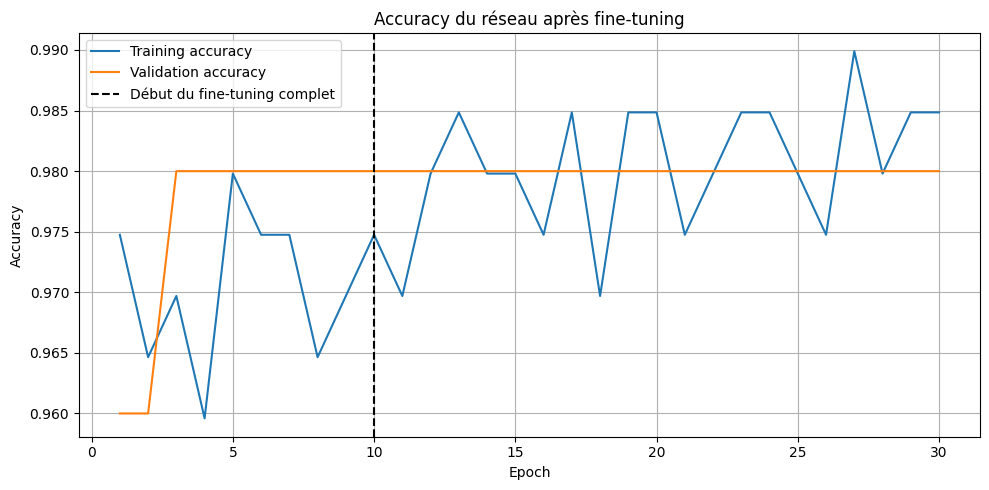

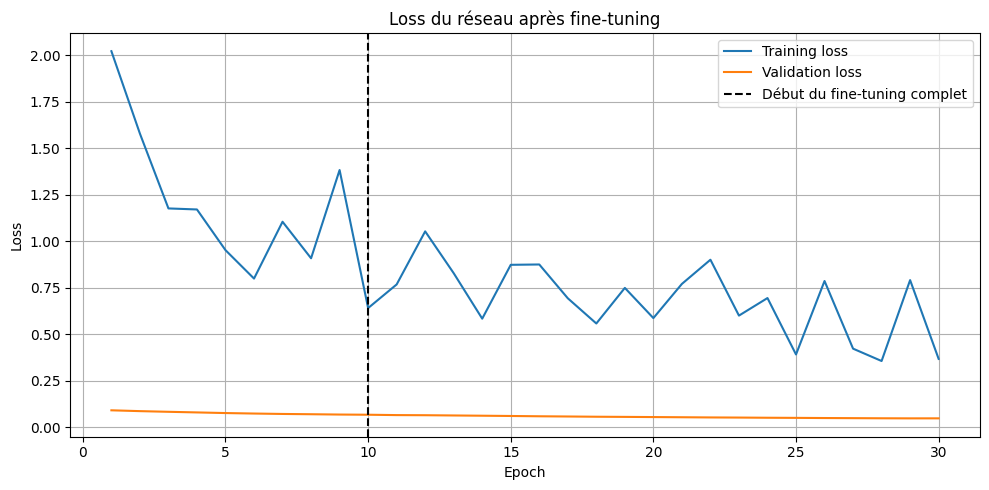

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/stepWARNING:tensorflow:6 out of the last 9 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x0000020EE647D3A0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step

Métriques - Validation après fine-tuning


Metric,Value
Area under ROC Curve,1.00
Weighted average Precision,0.97
Weighted average Recall,0.98
Weighted average F1 score,0.97


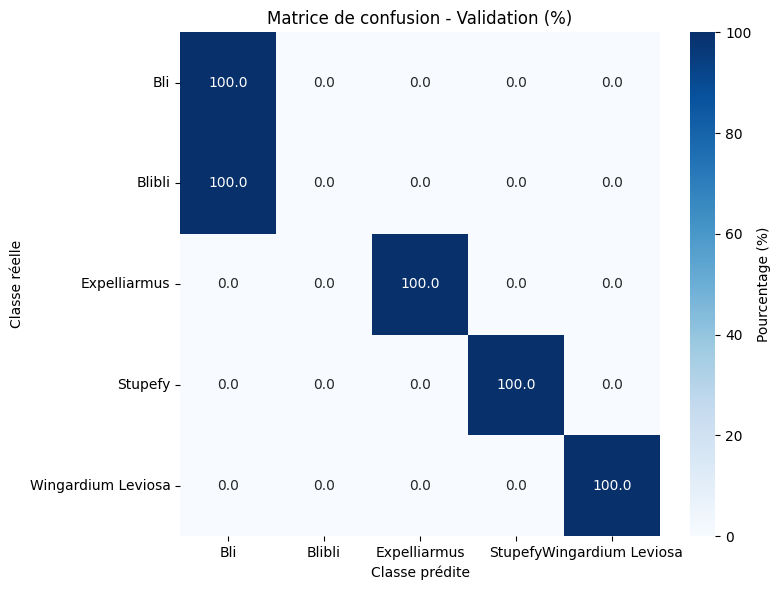

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step

Métriques - Test après fine-tuning


Metric,Value
Area under ROC Curve,1.00
Weighted average Precision,0.97
Weighted average Recall,0.98
Weighted average F1 score,0.98


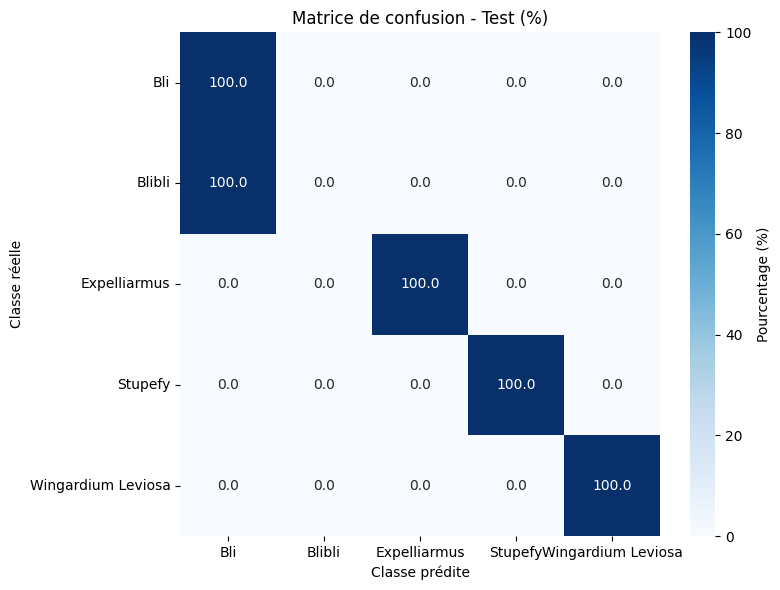


Fine-tuning terminé.
Anciennes classes : ['Bli', 'Expelliarmus', 'Stupefy', 'Wingardium Leviosa']
Nouvelles classes : ['Bli', 'Blibli', 'Expelliarmus', 'Stupefy', 'Wingardium Leviosa']
Classes ajoutées : ['Blibli']
Nouveau(x) label(s) : ['Blibli']
Classes embarquées : ['Bli', 'Blibli', 'Expelliarmus', 'Stupefy', 'Wingardium Leviosa']


In [50]:
def fine_tuner_avec_nouveau_label(
    model_base,
    scaler_base,
    label_encoder_base,
    dataset,
    epochs_tete=10,
    epochs_completes=20,
    batch_size=16,
    random_state=42,
):
    import numpy as np
    import pandas as pd
    import tensorflow as tf
    import matplotlib.pyplot as plt
    import seaborn as sns

    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import LabelEncoder
    from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    )
    from sklearn.utils.class_weight import compute_class_weight

    # 1. Vérifier les labels et générer les mêmes features qu'en partie 1.
    anciens_labels = [str(x) for x in label_encoder_base.classes_]
    nouveaux_labels = sorted(dataset["label"].astype(str).unique())
    labels_ajoutes = sorted(set(nouveaux_labels) - set(anciens_labels))

    if not labels_ajoutes:
        raise ValueError(
            "Aucun nouveau label détecté. Enregistrez d'abord un nouveau geste."
        )

    features = construire_features(dataset)
    colonnes_features = [
        c for c in features.columns if c not in {"source_file", "label"}
    ]

    if len(colonnes_features) != len(scaler_base.mean_):
        raise ValueError(
            "Les features ne correspondent pas au scaler de la partie 1."
        )

    # 2. Nouveau découpage par acquisition, stratifié label par label.
    fichiers_train, fichiers_validation, fichiers_test = [], [], []
    for label in nouveaux_labels:
        fichiers = (
            features.loc[features["label"].astype(str) == label, "source_file"]
            .drop_duplicates()
            .tolist()
        )
        if len(fichiers) < 5:
            raise ValueError(
                f"Le label « {label} » ne contient que {len(fichiers)} "
                "acquisitions. Il en faut au moins 5, idéalement 10 à 20."
            )

        train_val, test = train_test_split(
            fichiers, test_size=0.20, random_state=random_state, shuffle=True
        )
        train, validation = train_test_split(
            train_val, test_size=0.20, random_state=random_state, shuffle=True
        )
        fichiers_train.extend(train)
        fichiers_validation.extend(validation)
        fichiers_test.extend(test)

    def selection(fichiers):
        subset = features[features["source_file"].isin(fichiers)].copy()
        X = subset[colonnes_features]
        y = subset["label"].astype(str)
        return X, y

    X_train, y_train = selection(fichiers_train)
    X_validation, y_validation = selection(fichiers_validation)
    X_test, y_test = selection(fichiers_test)

    # Le scaler original est volontairement conservé.
    X_train_scaled = scaler_base.transform(X_train)
    X_validation_scaled = scaler_base.transform(X_validation)
    X_test_scaled = scaler_base.transform(X_test)

    nouvel_encodeur = LabelEncoder()
    nouvel_encodeur.classes_ = np.asarray(nouveaux_labels, dtype=object)
    y_train_encoded = nouvel_encodeur.transform(y_train)
    y_validation_encoded = nouvel_encodeur.transform(y_validation)
    y_test_encoded = nouvel_encodeur.transform(y_test)

    # 3. Construire le réseau étendu et transférer les poids.
    anciennes_dense = [
        layer for layer in model_base.layers
        if isinstance(layer, tf.keras.layers.Dense)
    ]
    if len(anciennes_dense) != 3:
        raise ValueError("Le modèle de la partie 1 doit contenir 3 couches Dense.")

    units_1 = anciennes_dense[0].units
    units_2 = anciennes_dense[1].units
    input_size = X_train_scaled.shape[1]

    modele_finetune = tf.keras.Sequential([
        tf.keras.Input(shape=(input_size,)),
        tf.keras.layers.Dense(units_1, activation="relu", name="dense_1"),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(units_2, activation="relu", name="dense_2"),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(
            len(nouveaux_labels), activation="softmax", name="sortie_etendue"
        ),
    ])

    modele_finetune.get_layer("dense_1").set_weights(
        anciennes_dense[0].get_weights()
    )
    modele_finetune.get_layer("dense_2").set_weights(
        anciennes_dense[1].get_weights()
    )

    old_w, old_b = anciennes_dense[2].get_weights()
    new_layer = modele_finetune.get_layer("sortie_etendue")
    new_w, new_b = new_layer.get_weights()

    for old_index, label in enumerate(anciens_labels):
        new_index = nouveaux_labels.index(label)
        new_w[:, new_index] = old_w[:, old_index]
        new_b[new_index] = old_b[old_index]

    for label in labels_ajoutes:
        new_index = nouveaux_labels.index(label)
        new_w[:, new_index] = 0.0
        new_b[new_index] = 0.0

    new_layer.set_weights([new_w, new_b])

    classes = np.unique(y_train_encoded)
    poids = compute_class_weight(
        class_weight="balanced", classes=classes, y=y_train_encoded
    )
    class_weight = dict(zip(classes.tolist(), poids.tolist()))

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=6, restore_best_weights=True
    )

    # 4. Phase 1 : entraîner uniquement la nouvelle tête.
    modele_finetune.get_layer("dense_1").trainable = False
    modele_finetune.get_layer("dense_2").trainable = False
    modele_finetune.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    print("Phase 1/2 : adaptation de la couche de sortie")
    historique_tete = modele_finetune.fit(
        X_train_scaled,
        y_train_encoded,
        validation_data=(X_validation_scaled, y_validation_encoded),
        epochs=epochs_tete,
        batch_size=batch_size,
        class_weight=class_weight,
        callbacks=[early_stop],
        verbose=1,
    )

    # 5. Phase 2 : ajustement léger de tout le réseau.
    modele_finetune.get_layer("dense_1").trainable = True
    modele_finetune.get_layer("dense_2").trainable = True
    modele_finetune.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    print("Phase 2/2 : ajustement fin de toutes les couches")
    historique_complet = modele_finetune.fit(
        X_train_scaled,
        y_train_encoded,
        validation_data=(X_validation_scaled, y_validation_encoded),
        epochs=epochs_completes,
        batch_size=batch_size,
        class_weight=class_weight,
        callbacks=[early_stop],
        verbose=1,
    )

    # --------------------------------------------------------
    # 6. Regroupement des historiques des deux phases
    # --------------------------------------------------------

    accuracy_complete = (
        historique_tete.history["accuracy"]
        + historique_complet.history["accuracy"]
    )

    val_accuracy_complete = (
        historique_tete.history["val_accuracy"]
        + historique_complet.history["val_accuracy"]
    )

    loss_complete = (
        historique_tete.history["loss"]
        + historique_complet.history["loss"]
    )

    val_loss_complete = (
        historique_tete.history["val_loss"]
        + historique_complet.history["val_loss"]
    )

    epochs_complete = range(1, len(accuracy_complete) + 1)
    fin_phase_tete = len(historique_tete.history["accuracy"])

    # --------------------------------------------------------
    # 7. Courbe de l'accuracy
    # --------------------------------------------------------

    plt.figure(figsize=(10, 5))

    plt.plot(
        epochs_complete,
        accuracy_complete,
        label="Training accuracy",
    )

    plt.plot(
        epochs_complete,
        val_accuracy_complete,
        label="Validation accuracy",
    )

    plt.axvline(
        x=fin_phase_tete,
        color="black",
        linestyle="--",
        label="Début du fine-tuning complet",
    )

    plt.title("Accuracy du réseau après fine-tuning")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # 8. Courbe de la loss
    # --------------------------------------------------------

    plt.figure(figsize=(10, 5))

    plt.plot(
        epochs_complete,
        loss_complete,
        label="Training loss",
    )

    plt.plot(
        epochs_complete,
        val_loss_complete,
        label="Validation loss",
    )

    plt.axvline(
        x=fin_phase_tete,
        color="black",
        linestyle="--",
        label="Début du fine-tuning complet",
    )

    plt.title("Loss du réseau après fine-tuning")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # Fonctions d'affichage des métriques
    # --------------------------------------------------------

    def calculer_et_afficher_metriques(
        y_true,
        y_pred,
        y_proba,
        titre,
    ):
        """
        Calcule les mêmes métriques que dans la partie 1.
        """

        metrics = pd.DataFrame({
            "Metric": [
                "Area under ROC Curve",
                "Weighted average Precision",
                "Weighted average Recall",
                "Weighted average F1 score",
            ],
            "Value": [
                roc_auc_score(
                    y_true,
                    y_proba,
                    multi_class="ovr",
                    average="weighted",
                    labels=np.arange(len(nouveaux_labels)),
                ),
                precision_score(
                    y_true,
                    y_pred,
                    average="weighted",
                    zero_division=0,
                ),
                recall_score(
                    y_true,
                    y_pred,
                    average="weighted",
                    zero_division=0,
                ),
                f1_score(
                    y_true,
                    y_pred,
                    average="weighted",
                    zero_division=0,
                ),
            ],
        })

        metrics["Value"] = metrics["Value"].map(
            lambda valeur: f"{valeur:.2f}"
        )

        print(f"\n{titre}")
        display(metrics.style.hide(axis="index"))

        return metrics

    def afficher_matrice_confusion_finetuning(
        y_true,
        y_pred,
        titre,
    ):
        """
        Affiche une matrice de confusion normalisée par classe.
        """

        matrice = confusion_matrix(
            y_true,
            y_pred,
            labels=np.arange(len(nouveaux_labels)),
        )

        sommes_lignes = matrice.sum(
            axis=1,
            keepdims=True,
        )

        pourcentages = np.divide(
            matrice,
            sommes_lignes,
            out=np.zeros_like(
                matrice,
                dtype=float,
            ),
            where=sommes_lignes != 0,
        ) * 100

        plt.figure(figsize=(8, 6))

        sns.heatmap(
            pourcentages,
            annot=True,
            fmt=".1f",
            cmap="Blues",
            xticklabels=nouveaux_labels,
            yticklabels=nouveaux_labels,
            vmin=0,
            vmax=100,
            cbar_kws={
                "label": "Pourcentage (%)",
            },
        )

        plt.title(titre)
        plt.xlabel("Classe prédite")
        plt.ylabel("Classe réelle")
        plt.tight_layout()
        plt.show()

        return matrice

    # --------------------------------------------------------
    # 9. Évaluation sur les données de validation
    # --------------------------------------------------------

    validation_proba = modele_finetune.predict(
        X_validation_scaled
    )

    validation_pred = np.argmax(
        validation_proba,
        axis=1,
    )

    validation_metrics = calculer_et_afficher_metriques(
        y_validation_encoded,
        validation_pred,
        validation_proba,
        "Métriques - Validation après fine-tuning",
    )

    validation_confusion = (
        afficher_matrice_confusion_finetuning(
            y_validation_encoded,
            validation_pred,
            "Matrice de confusion - Validation (%)",
        )
    )

    # --------------------------------------------------------
    # 10. Évaluation sur les données de test
    # --------------------------------------------------------

    test_proba = modele_finetune.predict(
        X_test_scaled
    )

    test_pred = np.argmax(
        test_proba,
        axis=1,
    )

    test_metrics = calculer_et_afficher_metriques(
        y_test_encoded,
        test_pred,
        test_proba,
        "Métriques - Test après fine-tuning",
    )

    test_confusion = (
        afficher_matrice_confusion_finetuning(
            y_test_encoded,
            test_pred,
            "Matrice de confusion - Test (%)",
        )
    )

    # --------------------------------------------------------
    # 11. Résumé
    # --------------------------------------------------------

    print("\nFine-tuning terminé.")
    print("Anciennes classes :", anciens_labels)
    print("Nouvelles classes :", nouveaux_labels)
    print("Classes ajoutées :", labels_ajoutes)

    return {
        "model": modele_finetune,
        "scaler": scaler_base,
        "label_encoder": nouvel_encodeur,
        "labels_ajoutes": labels_ajoutes,

        "history_head": historique_tete,
        "history_full": historique_complet,

        "accuracy": accuracy_complete,
        "val_accuracy": val_accuracy_complete,
        "loss": loss_complete,
        "val_loss": val_loss_complete,

        "validation_metrics": validation_metrics,
        "validation_confusion": validation_confusion,
        "test_metrics": test_metrics,
        "test_confusion": test_confusion,

        "features": features,

        "X_validation_scaled": X_validation_scaled,
        "y_validation_encoded": y_validation_encoded,
        "validation_proba": validation_proba,
        "validation_pred": validation_pred,

        "X_test_scaled": X_test_scaled,
        "y_test_encoded": y_test_encoded,
        "test_proba": test_proba,
        "test_pred": test_pred,
    }


# Conserver explicitement les objets de la partie 1.
model_partie1 = model
scaler_partie1 = scaler
label_encoder_partie1 = label_encoder

resultats_finetuning = fine_tuner_avec_nouveau_label(
    model_partie1,
    scaler_partie1,
    label_encoder_partie1,
    data,
    epochs_tete=10,
    epochs_completes=20,
    batch_size=16,
)

# Ces variables deviennent le modèle étendu utilisé pour l'export.
model = resultats_finetuning["model"]
scaler = resultats_finetuning["scaler"]
label_encoder = resultats_finetuning["label_encoder"]

print("Nouveau(x) label(s) :", resultats_finetuning["labels_ajoutes"])
print("Classes embarquées :", list(label_encoder.classes_))


## 4. Ré-embarquer le modèle adapté

La cellule suivante régénère `model_params.h` avec la classe supplémentaire, puis reprend exactement la compilation, le téléversement et le moniteur série de la partie 2.

Après le téléversement, la légende du moniteur série doit contenir le nouveau label et son nombre de clignotements.


In [51]:
# Export du modèle étendu issu du fine-tuning
exporter_modele_cpp(model, scaler, label_encoder)

# ============================================================
# Génération, compilation et téléversement du sketch Arduino
# Inference directe en C++ : Dense + ReLU + Softmax
# ============================================================

import os
import time
import shutil
import subprocess
import serial
from serial.tools import list_ports

def trouver_port_xiao():
    """
    Recherche automatiquement une Seeed XIAO nRF52840 connectée.

    Retourne par exemple "COM10" sous Windows ou
    "/dev/ttyACM0" sous Linux.
    """

    ports_detectes = list(list_ports.comports())
    candidats = []

    for port in ports_detectes:
        description = (
            f"{port.description} "
            f"{port.manufacturer} "
            f"{port.product}"
        ).lower()

        # VID USB utilisé par Seeed Studio.
        est_seeed = port.vid == 0x2886

        # Recherche complémentaire par le nom du périphérique.
        est_xiao = any(
            mot in description
            for mot in [
                "xiao",
                "nrf52840",
                "seeed",
            ]
        )

        if est_seeed or est_xiao:
            candidats.append(port)

    if len(candidats) == 1:
        port = candidats[0]

        print(
            "Carte détectée :",
            port.device,
            "-",
            port.description,
        )

        return port.device

    if len(candidats) > 1:
        liste = "\n".join(
            f"  - {port.device} : {port.description}"
            for port in candidats
        )

        raise RuntimeError(
            "Plusieurs cartes Seeed/XIAO ont été détectées :\n"
            f"{liste}\n"
            "Débranchez les cartes qui ne sont pas utilisées."
        )

    ports_disponibles = "\n".join(
        f"  - {port.device} : {port.description}"
        for port in ports_detectes
    )

    if not ports_disponibles:
        ports_disponibles = "  Aucun port série détecté."

    raise RuntimeError(
        "Aucune Seeed XIAO nRF52840 n'a été détectée.\n"
        "Vérifiez le câble USB et le pilote de la carte.\n\n"
        "Ports série disponibles :\n"
        f"{ports_disponibles}"
    )


def attendre_port_xiao(timeout=15):
    """
    Attend que la carte réapparaisse après le téléversement.
    """

    debut = time.time()
    derniere_erreur = None

    while time.time() - debut < timeout:
        try:
            return trouver_port_xiao()
        except RuntimeError as erreur:
            derniere_erreur = erreur
            time.sleep(0.5)

    raise RuntimeError(
        "La carte n'est pas réapparue après le téléversement."
    ) from derniere_erreur

# À adapter à votre ordinateur
BAUDRATE = 115200
ARDUINO_CLI = trouver_arduino_cli()
PORT = trouver_port_xiao()
FQBN = "Seeeduino:nrf52:xiaonRF52840Sense"

SKETCH_NAME = "deploiement_xiao_cpp"
SKETCH_DIR = r"C:\temp\deploiement_xiao_cpp"

os.makedirs(SKETCH_DIR, exist_ok=True)
ino_path = os.path.join(SKETCH_DIR, SKETCH_NAME + ".ino")

arduino_code = r"""
#include <Arduino.h>
#include <Adafruit_TinyUSB.h>
#include <Wire.h>
#include <LSM6DS3.h>
#include <math.h>
#include "model_params.h"

LSM6DS3 imu(I2C_MODE, 0x6A);

constexpr int LED_D0 = D0;
constexpr int LED_D1 = D1;

constexpr int SAMPLE_RATE_HZ = 50;
constexpr int N_SAMPLES = 250;
constexpr int N_AXES = 6;
constexpr int N_FFT = 20;
constexpr uint32_t SERIAL_BAUDRATE = 115200;
constexpr uint32_t SAMPLE_PERIOD_US = 1000000UL / SAMPLE_RATE_HZ;
constexpr float EPSILON = 1.0e-12f;

float samples[N_SAMPLES][N_AXES];
float features[N_FEATURES];
float hidden1[N_HIDDEN_1];
float hidden2[N_HIDDEN_2];
float probabilities[N_CLASSES];

static_assert(N_FEATURES == N_AXES * (3 + N_FFT),
              "N_FEATURES ne correspond pas au calcul des features");

void acquireWindow();
void computeFeatures();
void normalizeFeatures();
void predictDirectCpp(const float* input, float* output);
void blinkLed(int count);
void setAllLeds(bool on);

void setup() {
  Serial.begin(SERIAL_BAUDRATE);
  // Ne pas bloquer la carte si elle fonctionne ensuite sans câble USB.
  const uint32_t serialStart = millis();
  while (!Serial && millis() - serialStart < 3000) {}

  pinMode(LED_BUILTIN, OUTPUT);
  pinMode(LED_D0, OUTPUT);
  pinMode(LED_D1, OUTPUT);

  // Toutes les LED sont éteintes au démarrage.
  setAllLeds(false);

  if (imu.begin() != 0) {
    Serial.println("Erreur : IMU non detectee");
    while (true) delay(1000);
  }
    Serial.println("XIAO prete - inference C++ directe.");
    Serial.println();
    Serial.println("Correspondance labels / clignotements :");

    for (int i = 0; i < N_CLASSES; ++i) {
      Serial.print("  ");
      Serial.print(LABELS[i]);
      Serial.print(" : ");
      Serial.print(i + 1);
      Serial.println((i + 1 == 1) ? " clignotement" : " clignotements");
    }

    Serial.println();
}

void loop() {
  Serial.println("Preparez le geste...");
  delay(1000);

  // Les trois LED restent allumées pendant l'acquisition.
  setAllLeds(true);
  acquireWindow();
  setAllLeds(false);

  computeFeatures();
  normalizeFeatures();
  predictDirectCpp(features, probabilities);

  int best = 0;
  for (int i = 1; i < N_CLASSES; ++i) {
    if (probabilities[i] > probabilities[best]) best = i;
  }

  const int blinkCount = best + 1;

  Serial.print("Sort reconnu : ");
  Serial.print(LABELS[best]);

  Serial.print(" | Score : ");
  Serial.print(probabilities[best], 4);

  Serial.print(" | Clignotements attendus : ");
  Serial.println(blinkCount);

  blinkLed(blinkCount);
  delay(2000);
}

void acquireWindow() {
  uint32_t nextSample = micros();
  for (int i = 0; i < N_SAMPLES; ++i) {
    samples[i][0] = imu.readFloatAccelX();
    samples[i][1] = imu.readFloatAccelY();
    samples[i][2] = imu.readFloatAccelZ();
    samples[i][3] = imu.readFloatGyroX();
    samples[i][4] = imu.readFloatGyroY();
    samples[i][5] = imu.readFloatGyroZ();

    nextSample += SAMPLE_PERIOD_US;
    while ((int32_t)(micros() - nextSample) < 0) {}
  }
}

void computeFeatures() {
  int featureIndex = 0;

  for (int axis = 0; axis < N_AXES; ++axis) {
    float mean = 0.0f;

    for (int n = 0; n < N_SAMPLES; ++n) {
      mean += samples[n][axis];
    }

    mean /= N_SAMPLES;

    float m2 = 0.0f;
    float m3 = 0.0f;
    float m4 = 0.0f;

    for (int n = 0; n < N_SAMPLES; ++n) {
      const float x = samples[n][axis] - mean;
      const float x2 = x * x;

      m2 += x2;
      m3 += x2 * x;
      m4 += x2 * x2;
    }

    m2 /= N_SAMPLES;
    m3 /= N_SAMPLES;
    m4 /= N_SAMPLES;

    // Caractéristiques statistiques
    features[featureIndex++] = sqrtf(m2);

    features[featureIndex++] =
        (m2 > EPSILON)
            ? m3 / powf(m2, 1.5f)
            : 0.0f;

    features[featureIndex++] =
        (m2 > EPSILON)
            ? m4 / (m2 * m2) - 3.0f
            : 0.0f;

    // Coefficients FFT 1 à 20.
    // k = 0 est ignoré car la composante continue a déjà été retirée.
    for (int k = 1; k <= N_FFT; ++k) {
      float re = 0.0f;
      float im = 0.0f;

      for (int n = 0; n < N_SAMPLES; ++n) {
        const float x = samples[n][axis] - mean;
        const float angle =
            -2.0f * PI * static_cast<float>(k * n)
            / static_cast<float>(N_SAMPLES);

        re += x * cosf(angle);
        im += x * sinf(angle);
      }

      features[featureIndex++] = re * re + im * im;
    }
  }
}

void normalizeFeatures() {
  for (int i = 0; i < N_FEATURES; ++i) {
    features[i] = (features[i] - SCALER_MEAN[i]) / SCALER_SCALE[i];
  }
}

void denseRelu(const float* input, int inputSize,
               const float* weights, const float* bias,
               float* output, int outputSize) {
  for (int j = 0; j < outputSize; ++j) {
    float sum = bias[j];
    for (int i = 0; i < inputSize; ++i) {
      // Matrices Keras exportées en ordre [entrée, sortie].
      sum += input[i] * weights[i * outputSize + j];
    }
    output[j] = (sum > 0.0f) ? sum : 0.0f;
  }
}

void denseLinear(const float* input, int inputSize,
                 const float* weights, const float* bias,
                 float* output, int outputSize) {
  for (int j = 0; j < outputSize; ++j) {
    float sum = bias[j];
    for (int i = 0; i < inputSize; ++i) {
      sum += input[i] * weights[i * outputSize + j];
    }
    output[j] = sum;
  }
}

void softmax(float* values, int size) {
  float maximum = values[0];
  for (int i = 1; i < size; ++i) maximum = max(maximum, values[i]);

  float total = 0.0f;
  for (int i = 0; i < size; ++i) {
    values[i] = expf(values[i] - maximum); // stabilisation numérique
    total += values[i];
  }
  if (total <= 0.0f) return;
  for (int i = 0; i < size; ++i) values[i] /= total;
}

void predictDirectCpp(const float* input, float* output) {
  denseRelu(
      input,
      N_FEATURES,
      MODEL_W1,
      MODEL_B1,
      hidden1,
      N_HIDDEN_1
  );

  denseRelu(
      hidden1,
      N_HIDDEN_1,
      MODEL_W2,
      MODEL_B2,
      hidden2,
      N_HIDDEN_2
  );

  denseLinear(
      hidden2,
      N_HIDDEN_2,
      MODEL_W3,
      MODEL_B3,
      output,
      N_CLASSES
  );

  softmax(output, N_CLASSES);
}

void setAllLeds(bool on) {
  // LED utilisateur : logique inversée.
  digitalWrite(
      LED_BUILTIN,
      on ? LOW : HIGH
  );

  // LED externes D0 et D1 : logique normale.
  digitalWrite(
      LED_D0,
      on ? HIGH : LOW
  );

  digitalWrite(
      LED_D1,
      on ? HIGH : LOW
  );
}

void blinkLed(int count) {
  for (int i = 0; i < count; ++i) {
    setAllLeds(true);
    delay(250);

    setAllLeds(false);
    delay(250);
  }
}
"""

if not os.path.exists("model_params.h"):
    raise FileNotFoundError("Exécutez d'abord la cellule qui génère model_params.h")

shutil.copy2("model_params.h", os.path.join(SKETCH_DIR, "model_params.h"))
with open(ino_path, "w", encoding="utf-8", newline="\n") as f:
    f.write(arduino_code)

print("Sketch généré :", ino_path)
print("Compilation en cours...")

compile_command = [
    ARDUINO_CLI,
    "compile",
    "--fqbn",
    FQBN,
    SKETCH_DIR,
]

compile_result = subprocess.run(
    compile_command,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    errors="replace",
)

if compile_result.returncode != 0:
    print("\n===== ERREUR DE COMPILATION =====\n")
    print(compile_result.stdout)
    print("\n===== FIN DE L'ERREUR =====\n")

    raise RuntimeError(
        f"Échec de la compilation Arduino "
        f"(code {compile_result.returncode})."
    )

print("Compilation réussie.")

print("Téléversement...")
upload_result = subprocess.run(
    [ARDUINO_CLI, "upload", "-p", PORT, "--fqbn", FQBN, SKETCH_DIR],
    capture_output=True, text=True
)
print(upload_result.stdout)
print(upload_result.stderr)
if upload_result.returncode != 0:
    raise RuntimeError("Échec du téléversement Arduino")

print("Téléversement terminé. Ouverture du moniteur série...")

# La carte peut disparaître puis revenir sur un autre port après son redémarrage.
PORT = attendre_port_xiao(timeout=15)

print("Port utilisé pour le moniteur série :", PORT)

ser = None
try:
    ser = serial.Serial(PORT, BAUDRATE, timeout=1)
    time.sleep(2)
    while True:
        line = ser.readline().decode("utf-8", errors="ignore").strip()
        if line:
            print(line)
except KeyboardInterrupt:
    print("Moniteur série arrêté.")
finally:
    if ser is not None and ser.is_open:
        ser.close()


Fichier généré : \\netapp2\bassant-koum\Stage IA\Jupyter notebook\Sujet TP\model_params.h
Architecture : 138 -> 64 -> 32 -> 5
Labels : ['Bli', 'Blibli', 'Expelliarmus', 'Stupefy', 'Wingardium Leviosa']
Paramètres exportés : 11141
Mémoire approximative des poids en float32 : 43.5 Kio
Carte détectée : COM10 - Périphérique série USB (COM10)
Sketch généré : C:\temp\deploiement_xiao_cpp\deploiement_xiao_cpp.ino
Compilation en cours...
Compilation réussie.
Téléversement...
Upgrading target on COM9 with DFU package C:\Users\bassant-koum\AppData\Local\arduino\sketches\DC985BA50E9D451AC75E1C55D40CE02A\deploiement_xiao_cpp.ino.zip. Flow control is disabled, Single bank, Touch disabled
########################################
########################################
########################################
########################################
########################################
###
Activating new firmware
Device programmed.
New upload port: COM10 (serial)


Téléversement terminé. Ouvertu